# Les Miserables

In [1]:
import sys
import os
sys.path.append(os.path.abspath("..\\.."))
from Modules.latentspacemodel import *
from Modules.inference import *
from Modules.afteranalyses import *

## Network

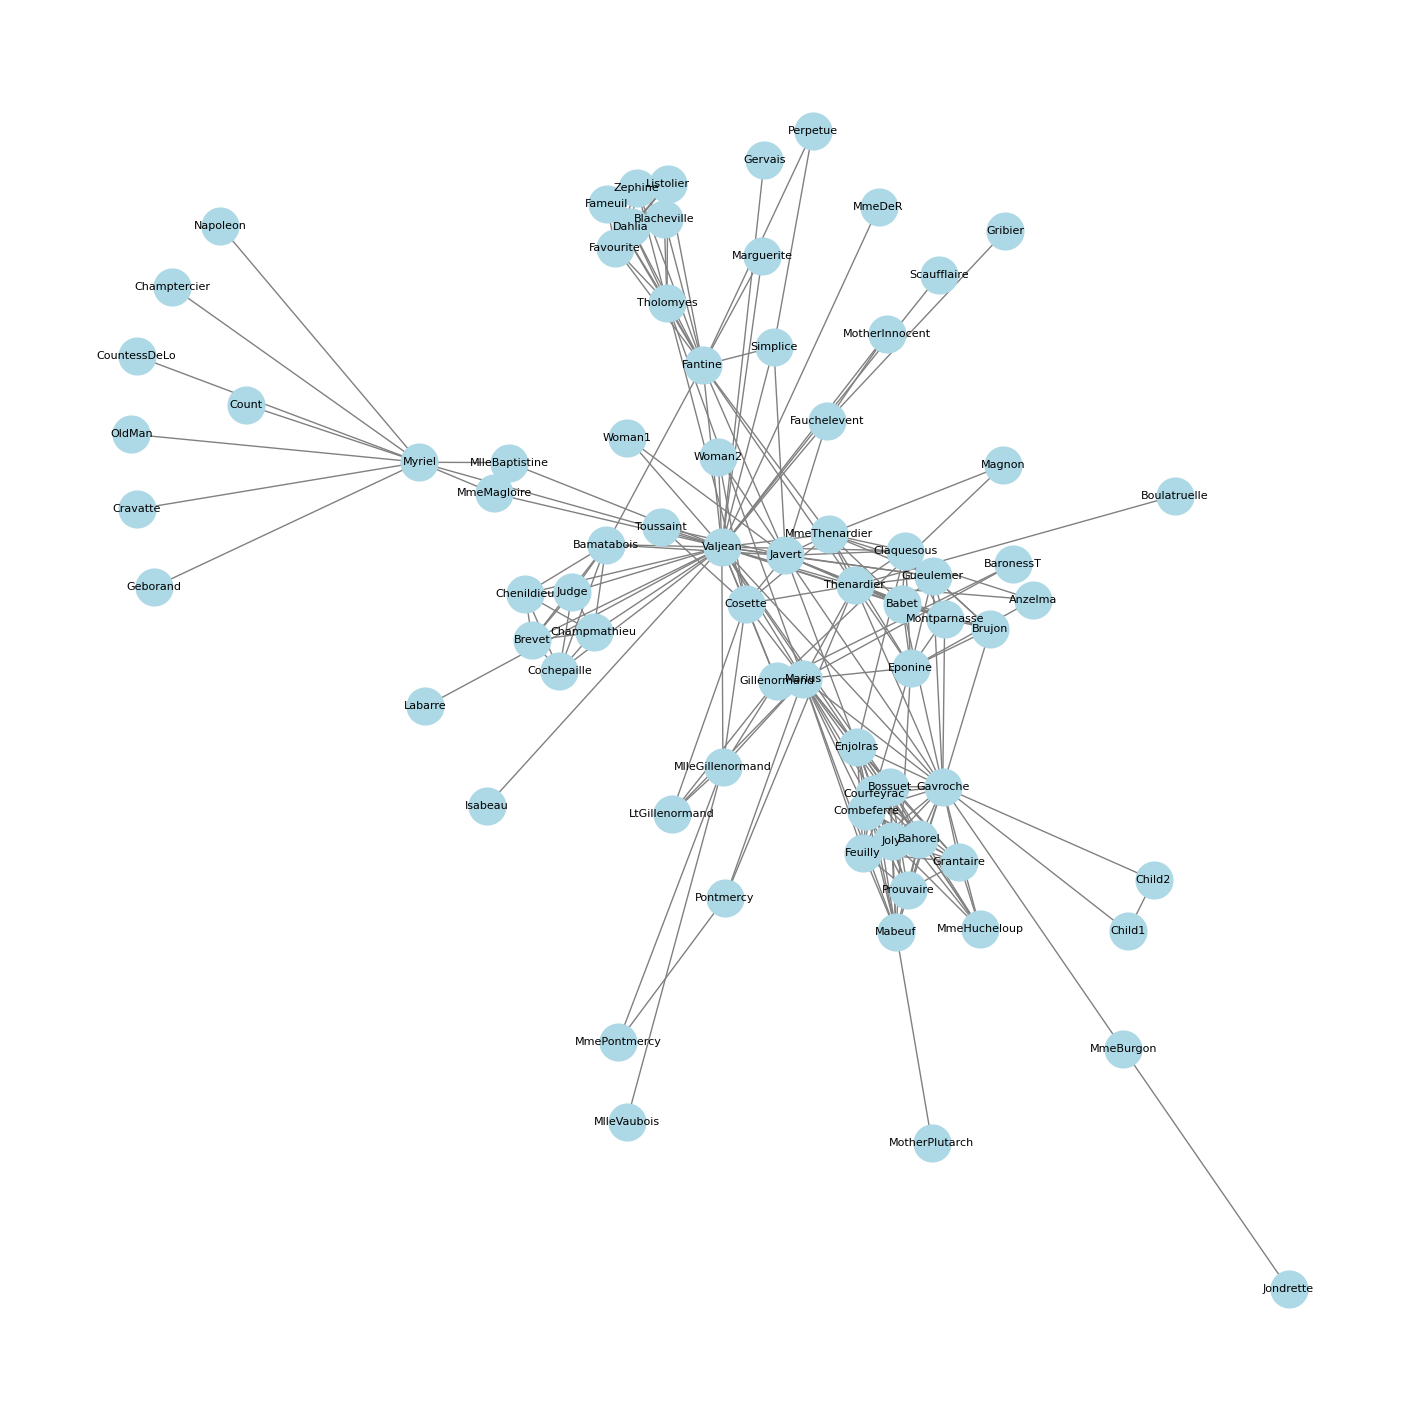

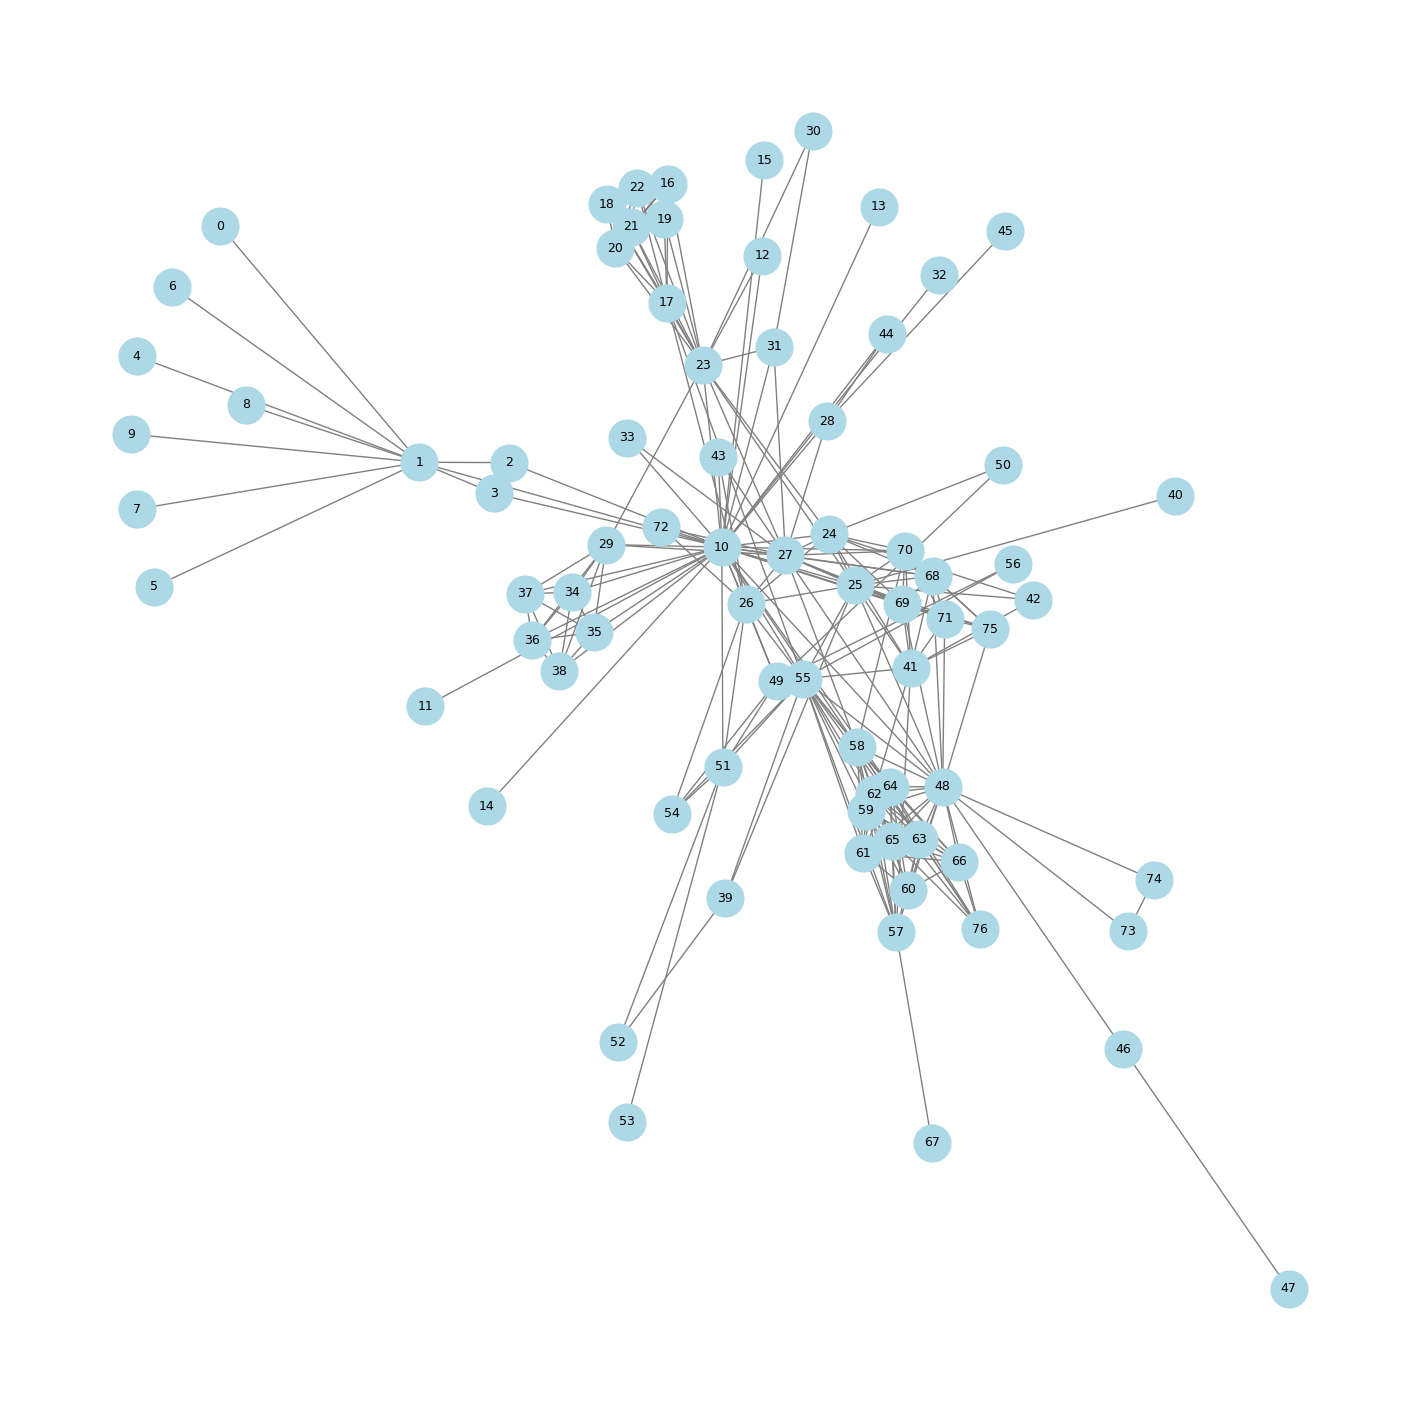

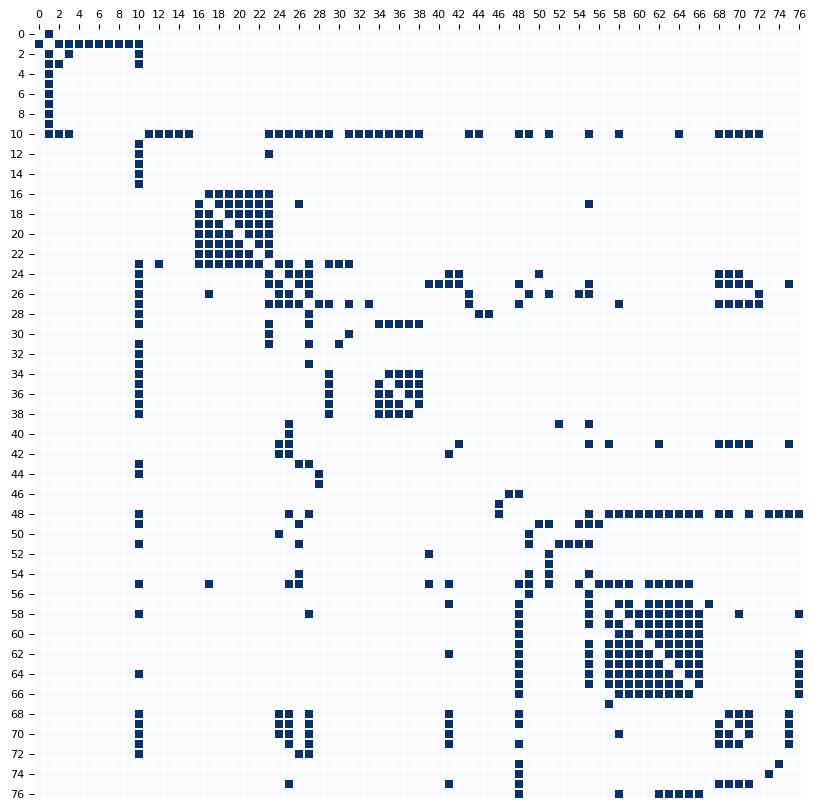

In [5]:
G = nx.les_miserables_graph()
G = nx.Graph(G) 
pos = nx.spring_layout(G, seed=80)
plt.figure(figsize=(14,14))
nx.draw(G,pos=pos,with_labels=True,node_color="lightblue",edge_color="gray",node_size=700,font_size=8)
plt.show()
node_mapping = {node: i for i, node in enumerate(G.nodes())}
G_num = nx.relabel_nodes(G, node_mapping)
pos_relabel = {node_mapping[k]: v for k, v in pos.items()}
plt.figure(figsize=(14,14))
nx.draw(G_num, pos=pos_relabel,with_labels=True,node_color="lightblue",edge_color="gray",node_size=700,font_size=9)
plt.show()
mapping_df = {i: node for node, i in node_mapping.items()}
#print(mapping_df)
Y = nx.to_numpy_array(G_num, dtype=float)
Y = (Y > 0).astype(int)
n = Y.shape[0]
plt.figure(figsize=(10,10))
sns.heatmap(Y,annot=False,cmap="Blues",cbar=False,square=True,linewidths=0.25,linecolor="white")
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.gca().xaxis.tick_top()
plt.gca().tick_params(top=True,bottom=False,labeltop=True,labelbottom=False,labelsize=8)
plt.show()

In [3]:
seed_MAP = 42
diam = 10.0
n = Y.shape[0]
lr_MAP = 1e-2
n_starts_MAP = 1
n_iter_MAP = 25000
n_sim_iv = 2500
n_iter_cv = 1000
n_folds_cv = 5

## Models over $\mathbb{R}^d$

### Model $\mathbb{R^1}$

#### Without weights

Multi_start (1)


MAP:  35%|███▍      | 8667/25000 [01:00<01:54, 143.06it/s, logpost=-686.6078, loglik=-685.9664, logprior=-0.6415, ||grad||=0.0141, patience=100]


[STOP] Early stopping at iter 8666 (no improvement in 101 steps)

Best log-posterior: -686.6078


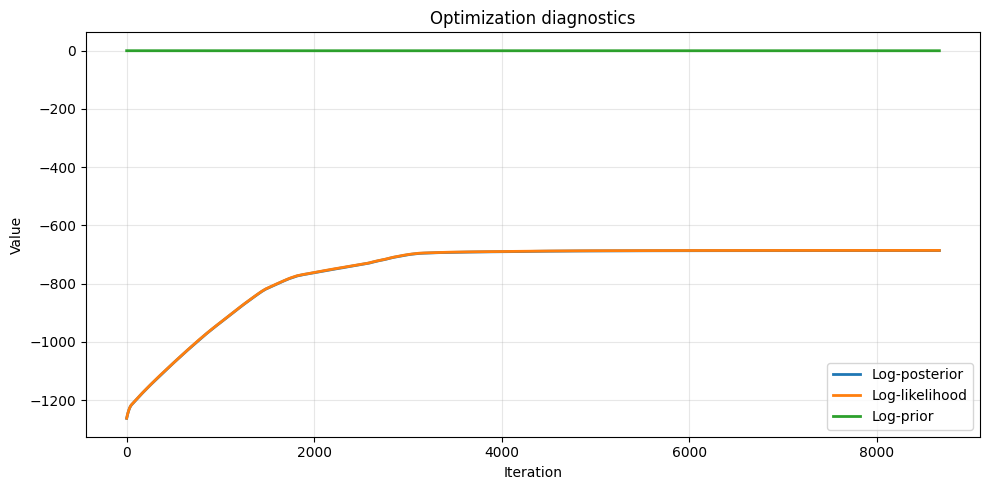

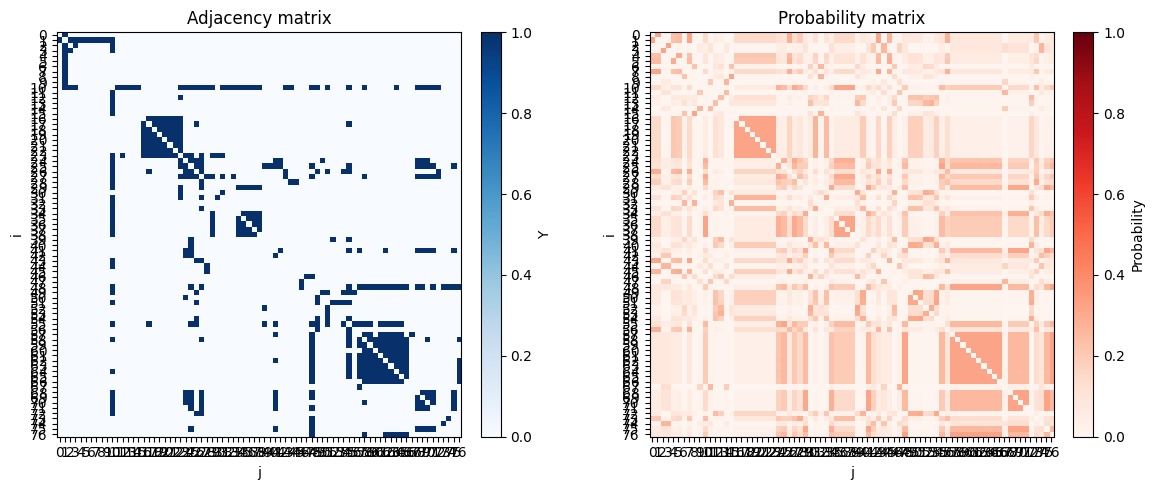

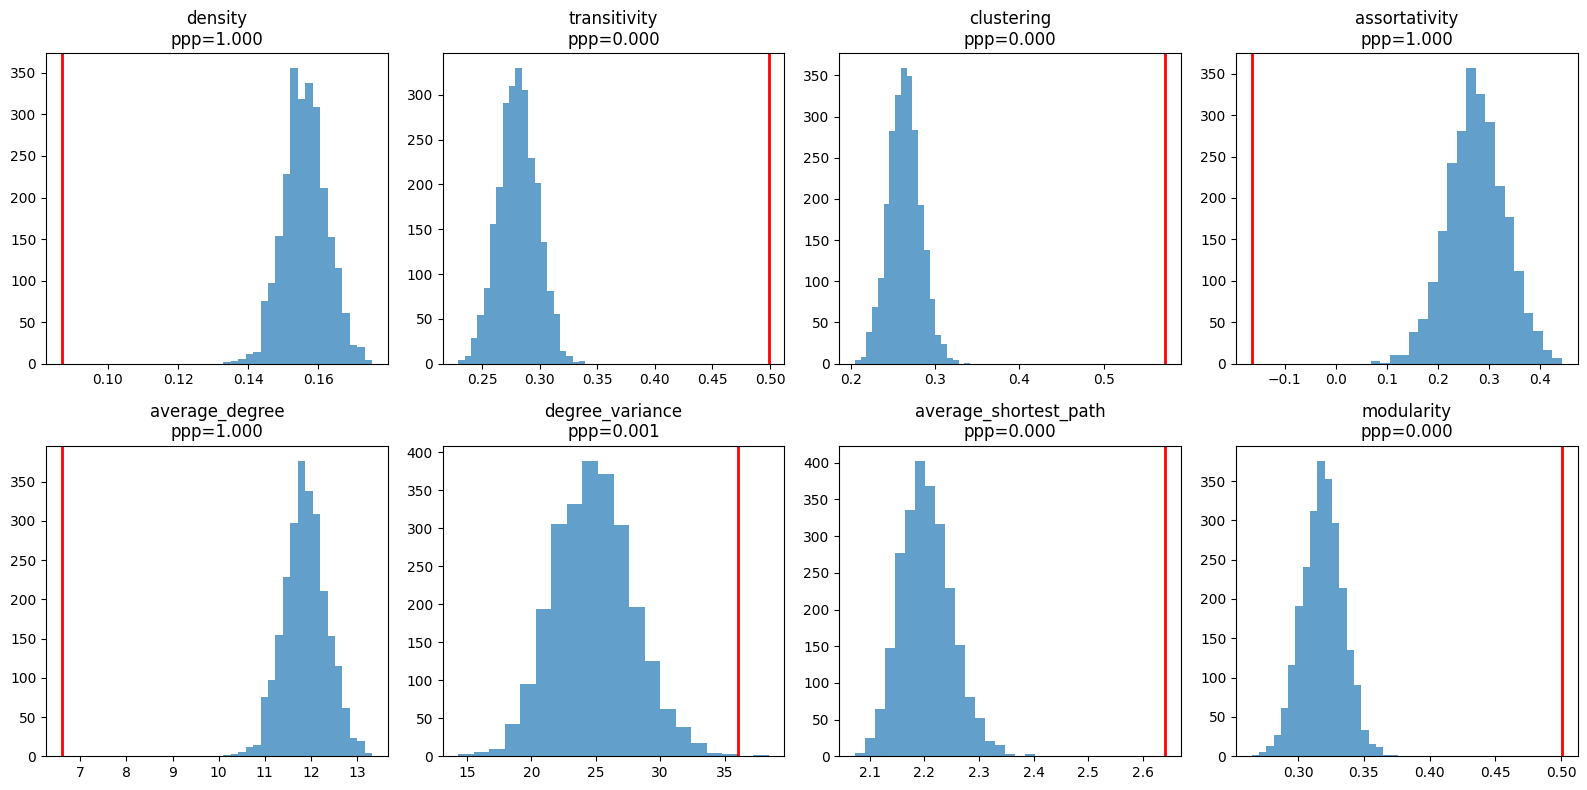

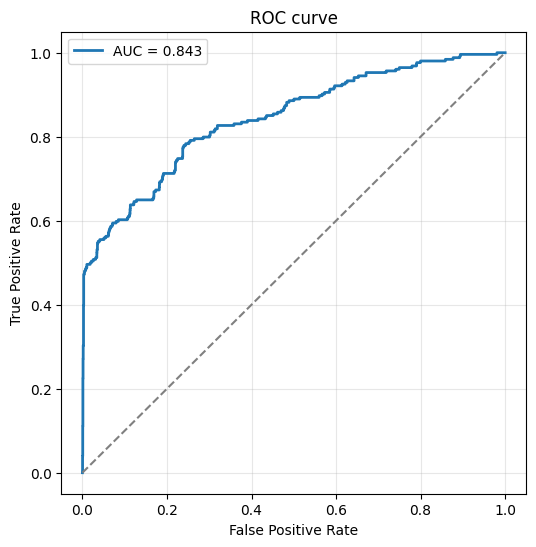

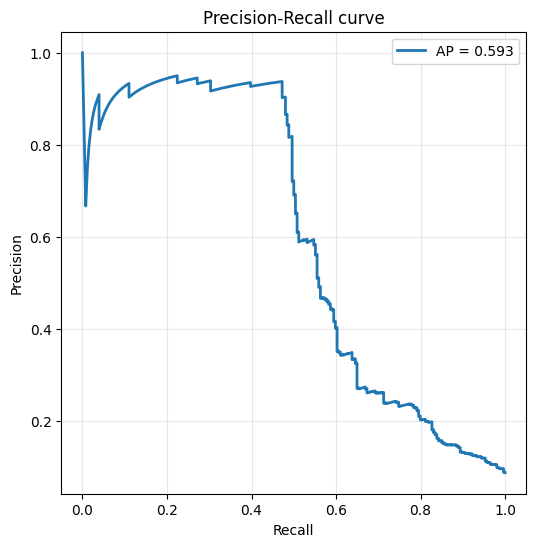

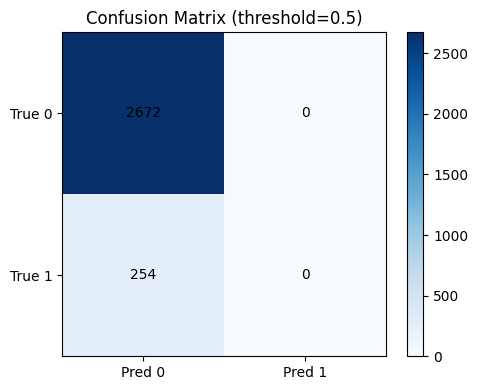

MAP: 100%|██████████| 1000/1000 [00:15<00:00, 64.79it/s, logpost=-540.9801, loglik=-540.3319, logprior=-0.6482, ||grad||=0.0140, patience=0]


{'mean_auc': 0.8131312085127371, 'std_auc': 0.04147338615512567, 'min_auc': np.float64(0.7637469021065676), 'max_auc': np.float64(0.8647718066432623), 'n_folds': 5}


In [6]:
geometry = EuclideanGeometry(d=1, D=diam)
model = LatentSpaceModel(Y=Y, geometry=geometry, fixed_params={"xi": np.ones(n)})
inference = MAPInference(model, lr=lr_MAP)
result = inference.fit_multi_start(n_starts=n_starts_MAP, n_iter=n_iter_MAP, verbose=True, use_tqdm=True)

analysis = ModelAnalysis(model,inference_key="MAP")
analysis.plot_logposterior_trace()
analysis.compare_with_adjacency(analysis.P,title="Probability matrix")
analysis.internal_validation(n_sim=n_sim_iv)
analysis.plot_ppc_distributions()
analysis.laplacian_validation() 
analysis.binary_prediction_metrics()
analysis.plot_roc_curve()
analysis.plot_precision_recall_curve()
analysis.confusion_matrix(threshold=0.5)
analysis.cross_validation(n_folds=n_folds_cv, seed=seed_MAP, n_iter=n_iter_cv, lr=lr_MAP)
print(analysis.cross_validation_summary())

model.save("LesMiserables_R1_c.pkl")

#### With weights

Multi_start (1)


MAP:  39%|███▊      | 9679/25000 [01:13<01:57, 130.83it/s, logpost=-593.5927, loglik=-593.5927, logprior=0.0000, ||grad||=0.0100, patience=100]


[STOP] Early stopping at iter 9678 (no improvement in 101 steps)

Best log-posterior: -593.5927


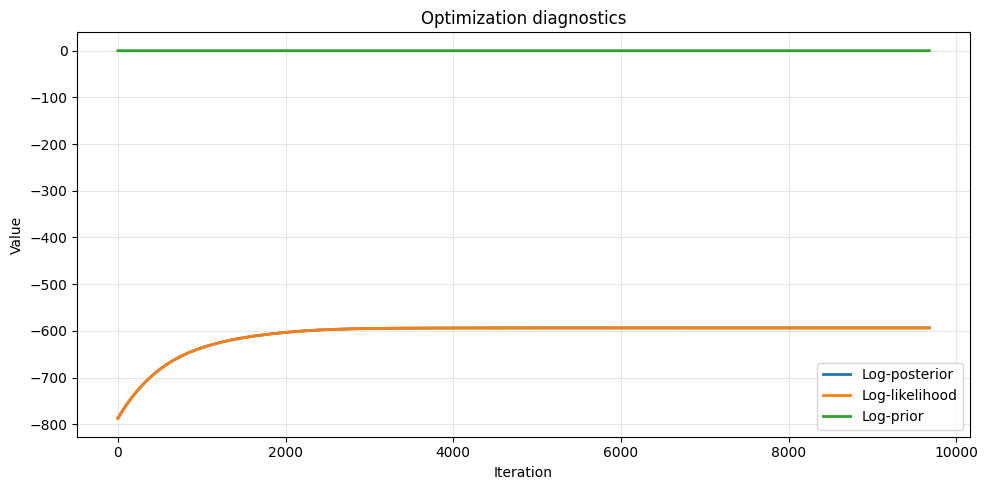

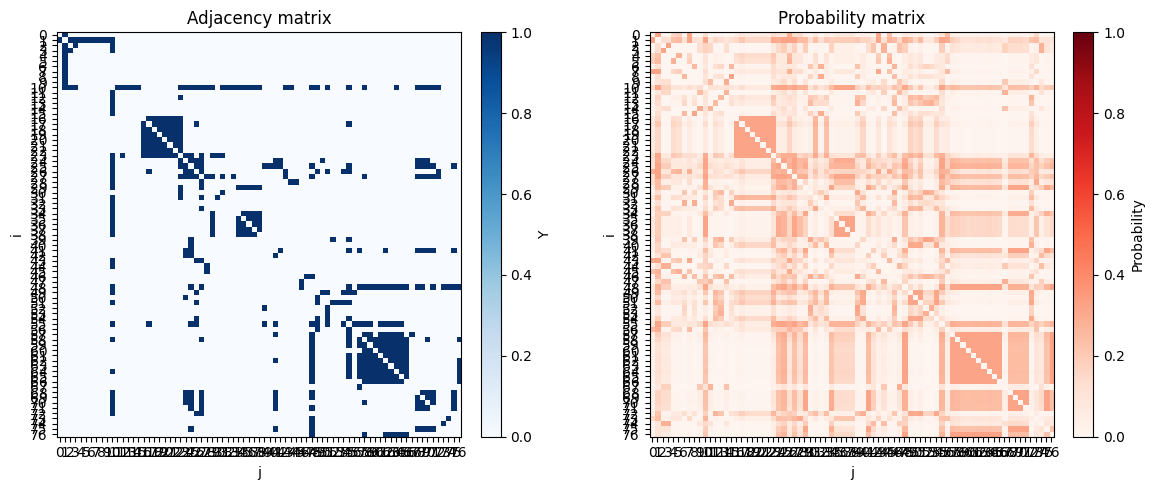

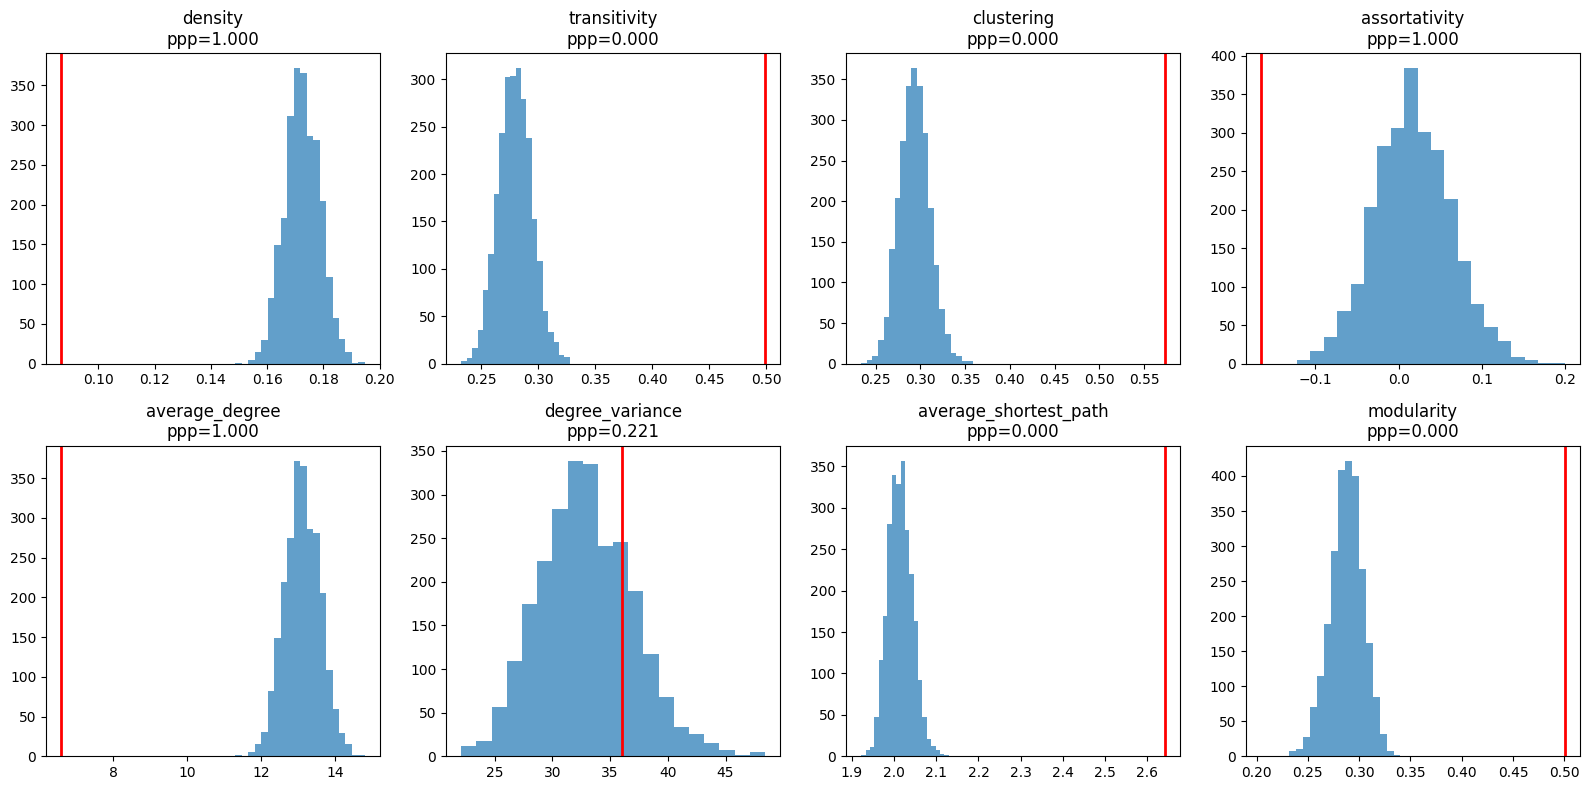

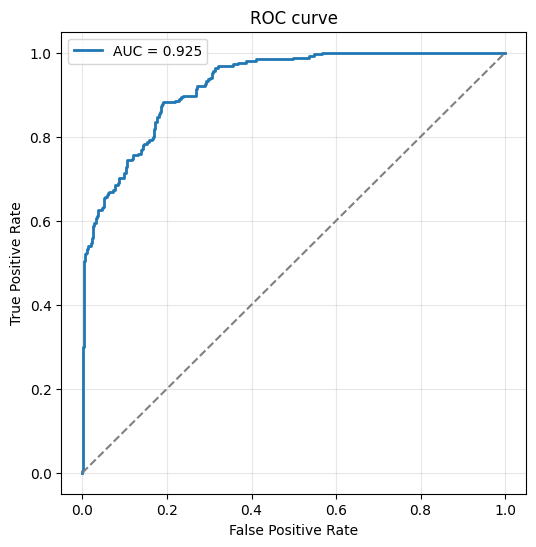

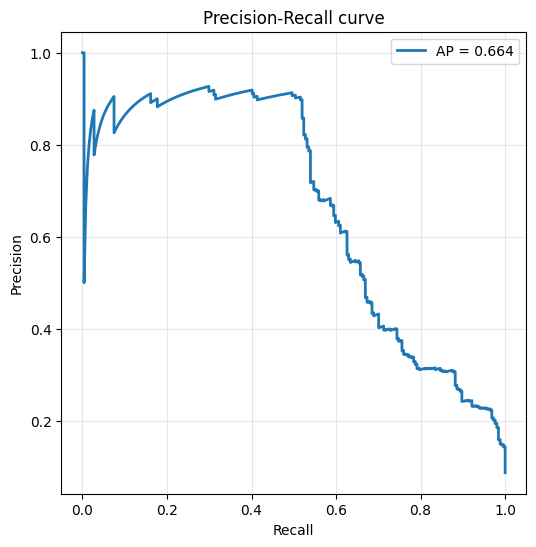

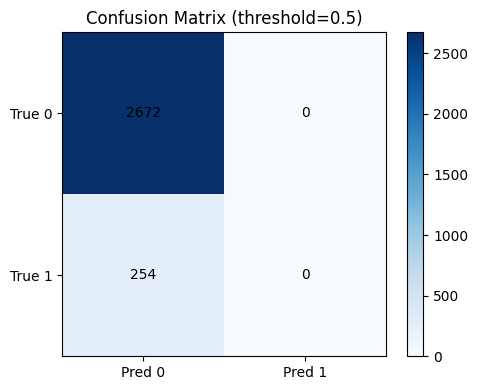

MAP: 100%|██████████| 1000/1000 [00:05<00:00, 190.86it/s, logpost=-472.4549, loglik=-472.4549, logprior=0.0000, ||grad||=0.0100, patience=0]


{'mean_auc': 0.9033729818857059, 'std_auc': 0.020587166813926663, 'min_auc': np.float64(0.8823962205700123), 'max_auc': np.float64(0.937111801242236), 'n_folds': 5}


In [7]:
geometry = EuclideanGeometry(d=1, D=diam)
alpha0 = model.inferred["MAP"]["final_params"]["alpha0"]
Z = model.inferred["MAP"]["final_params"]["Z"]
model = LatentSpaceModel(Y=Y, geometry=geometry, fixed_params={"Z": Z, "alpha0": alpha0})
inference = MAPInference(model, lr=lr_MAP)
result = inference.fit_multi_start(n_starts=n_starts_MAP, n_iter=n_iter_MAP, verbose=True, use_tqdm=True)

analysis = ModelAnalysis(model,inference_key="MAP")
analysis.plot_logposterior_trace()
analysis.compare_with_adjacency(analysis.P,title="Probability matrix")
analysis.internal_validation(n_sim=n_sim_iv)
analysis.plot_ppc_distributions()
analysis.laplacian_validation() 
analysis.binary_prediction_metrics()
analysis.plot_roc_curve()
analysis.plot_precision_recall_curve()
analysis.confusion_matrix(threshold=0.5)
analysis.cross_validation(n_folds=n_folds_cv, seed=seed_MAP, n_iter=n_iter_cv, lr=lr_MAP)
print(analysis.cross_validation_summary())

model.save("LesMiserables_R1_p.pkl")

### Model $\mathbb{R}^2$

#### Without weigths

Multi_start (1)


MAP: 100%|██████████| 25000/25000 [03:30<00:00, 118.78it/s, logpost=-459.5513, loglik=-458.8531, logprior=-0.6983, ||grad||=0.0140, patience=0] 



Best log-posterior: -459.5513


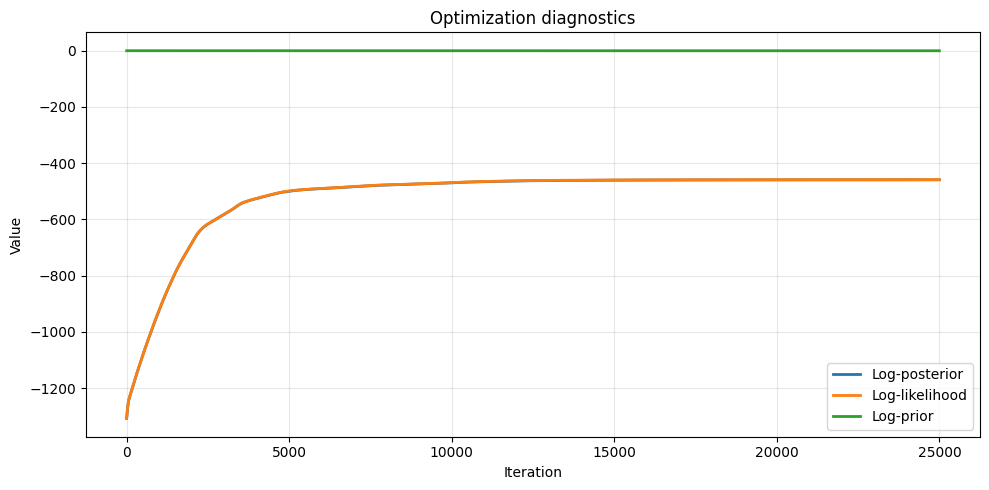

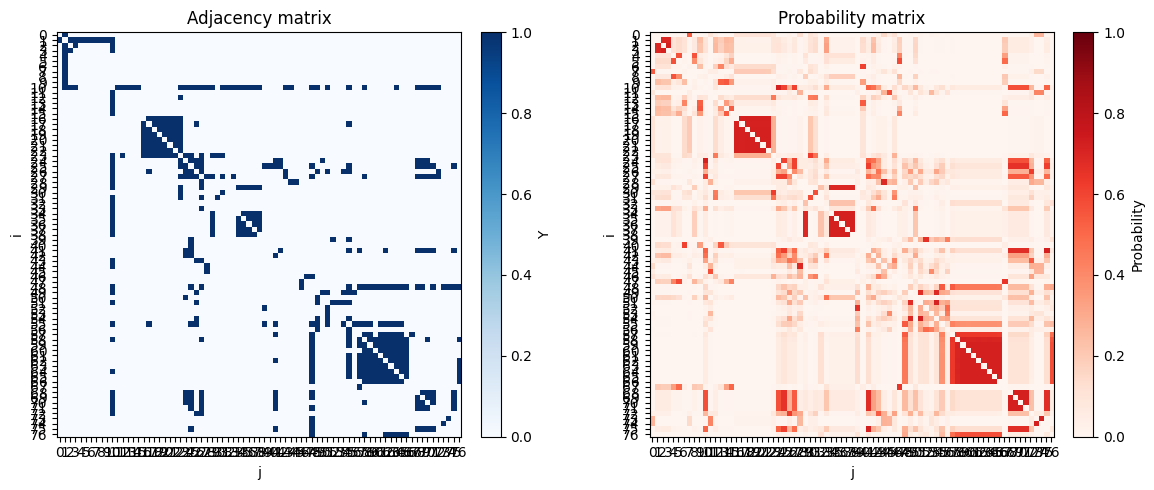

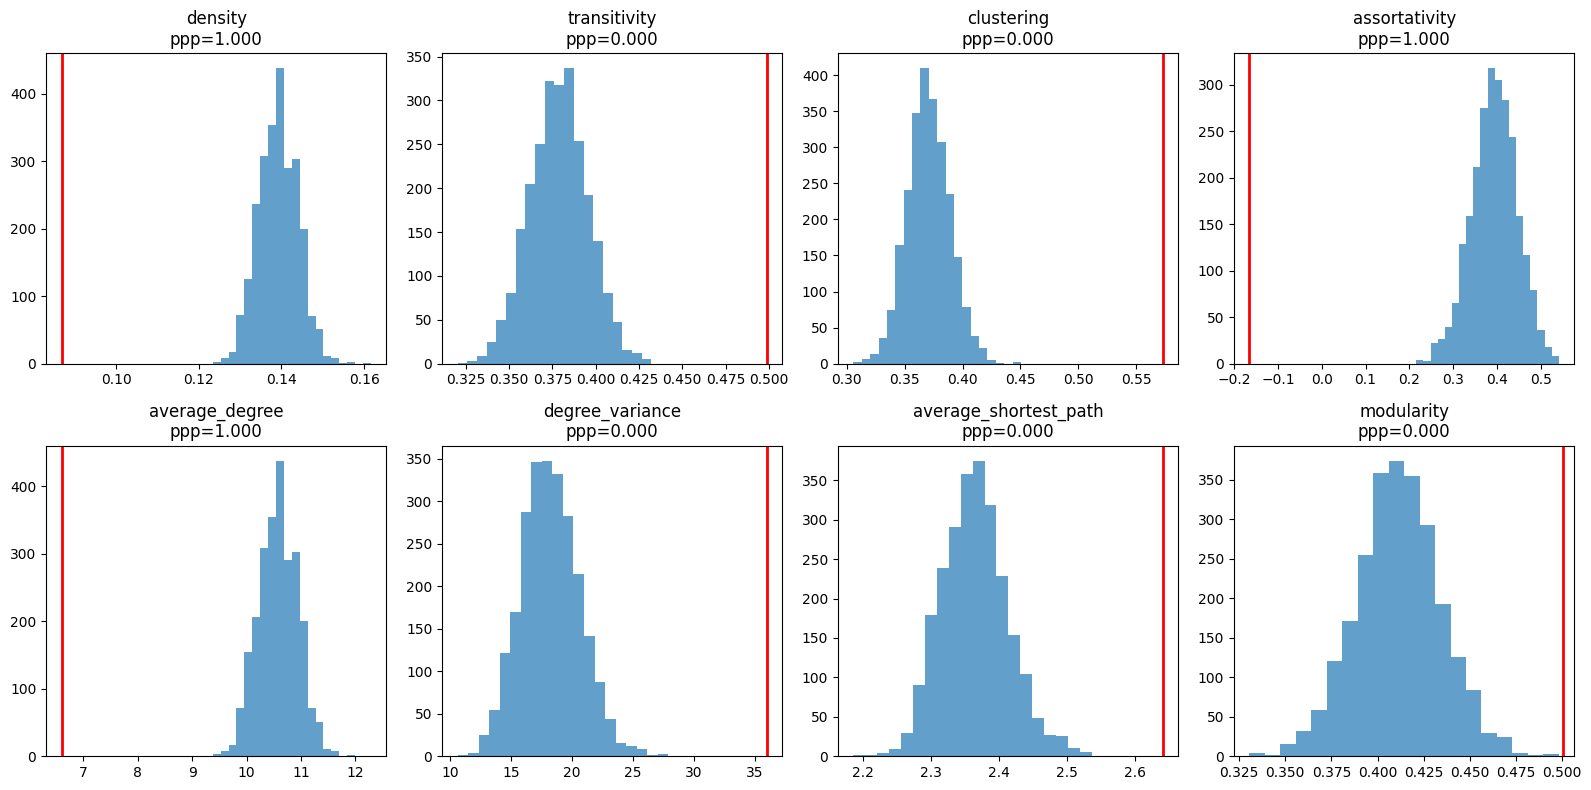

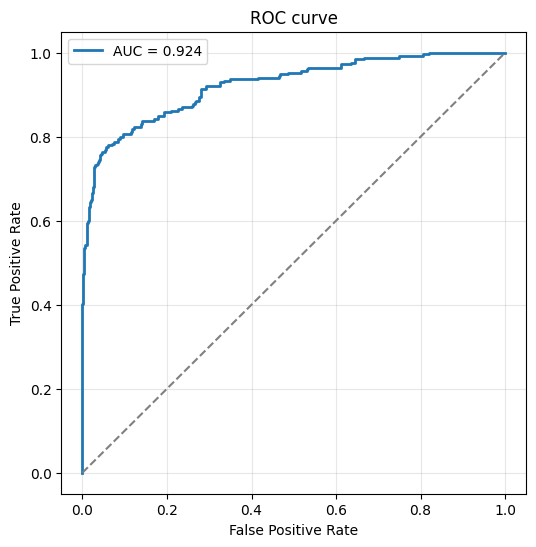

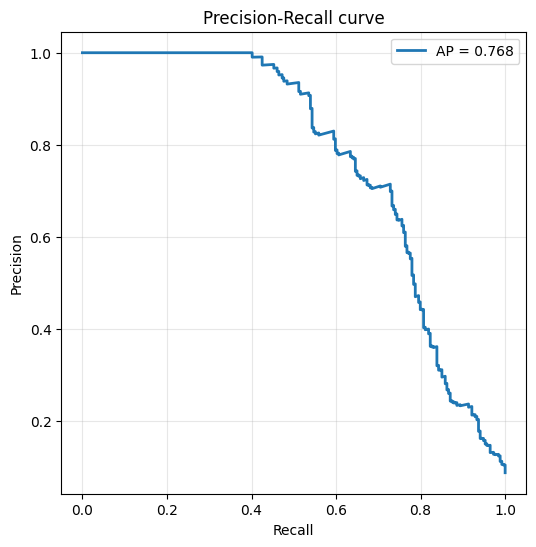

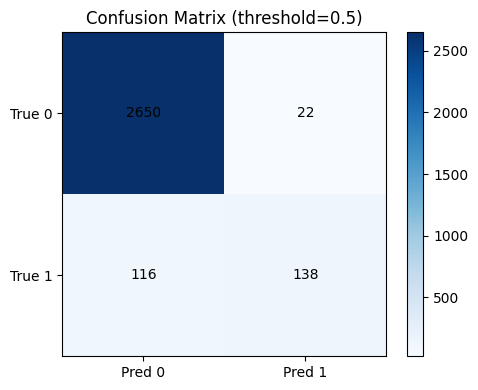

MAP: 100%|██████████| 1000/1000 [00:14<00:00, 69.03it/s, logpost=-359.9898, loglik=-359.2840, logprior=-0.7058, ||grad||=0.0140, patience=0]


{'mean_auc': 0.9011843460209674, 'std_auc': 0.018106089719516376, 'min_auc': np.float64(0.8776249335459861), 'max_auc': np.float64(0.9277803593556381), 'n_folds': 5}


In [8]:
geometry = EuclideanGeometry(d=2, D=diam)
model = LatentSpaceModel(Y=Y, geometry=geometry, fixed_params={"xi": np.ones(n)})
inference = MAPInference(model, lr=lr_MAP)
result = inference.fit_multi_start(n_starts=n_starts_MAP, n_iter=n_iter_MAP, verbose=True, use_tqdm=True)

analysis = ModelAnalysis(model,inference_key="MAP")
analysis.plot_logposterior_trace()
analysis.compare_with_adjacency(analysis.P,title="Probability matrix")
analysis.internal_validation(n_sim=n_sim_iv)
analysis.plot_ppc_distributions()
analysis.laplacian_validation() 
analysis.binary_prediction_metrics()
analysis.plot_roc_curve()
analysis.plot_precision_recall_curve()
analysis.confusion_matrix(threshold=0.5)
analysis.cross_validation(n_folds=n_folds_cv, seed=seed_MAP, n_iter=n_iter_cv, lr=lr_MAP)
print(analysis.cross_validation_summary())

model.save("LesMiserables_R2_c.pkl")

#### With weights

Multi_start (1)


MAP:  14%|█▍        | 3453/25000 [00:29<03:03, 117.46it/s, logpost=-368.7245, loglik=-368.7245, logprior=0.0000, ||grad||=0.0100, patience=100]


[STOP] Early stopping at iter 3452 (no improvement in 101 steps)

Best log-posterior: -368.7245


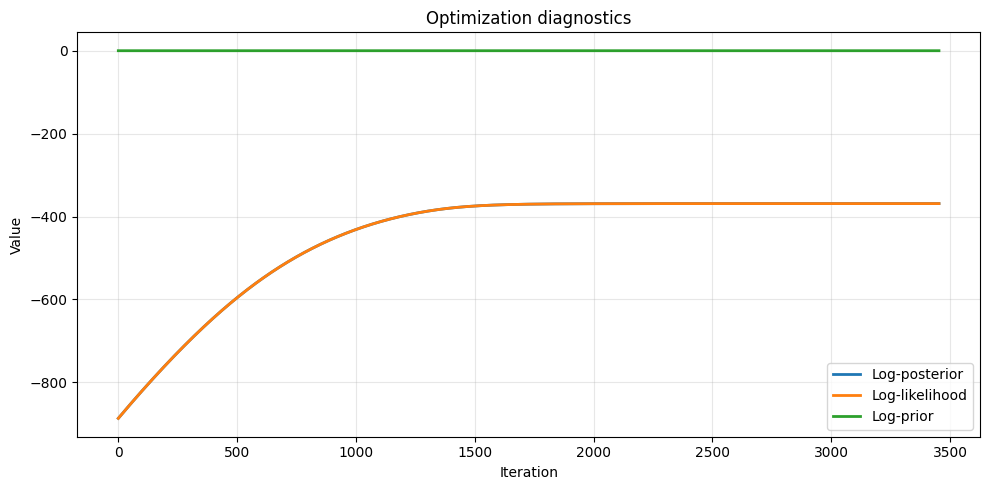

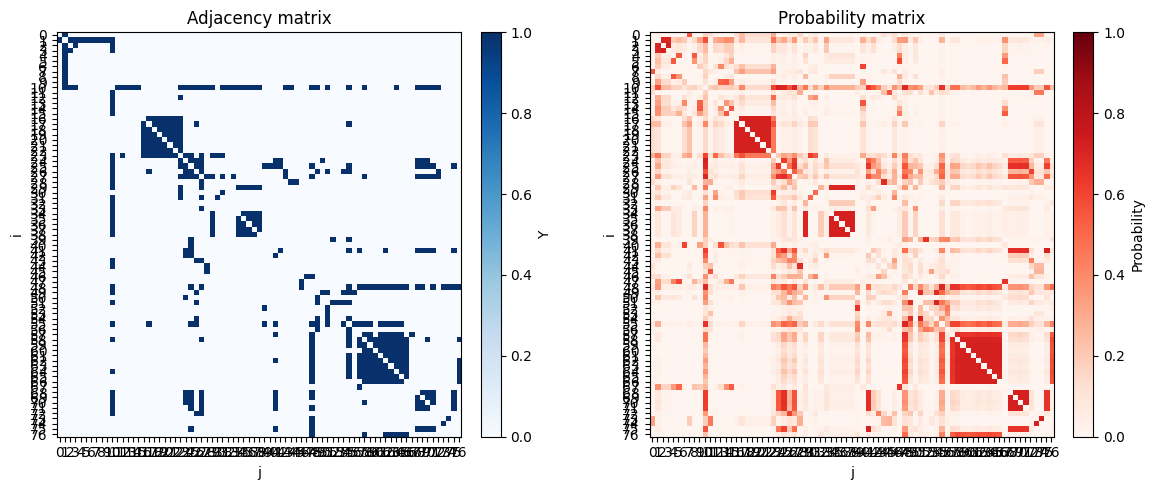

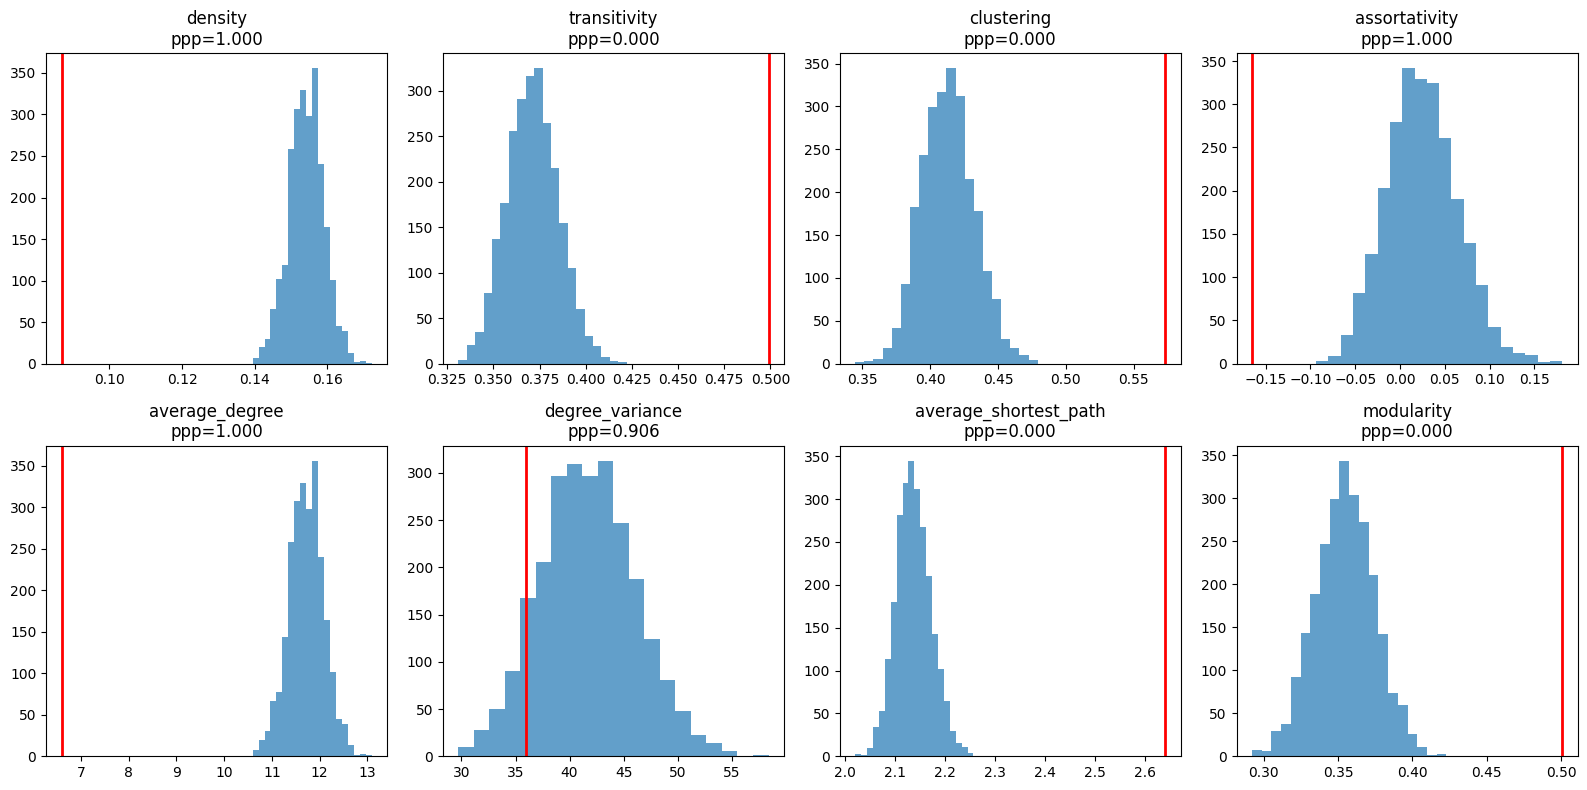

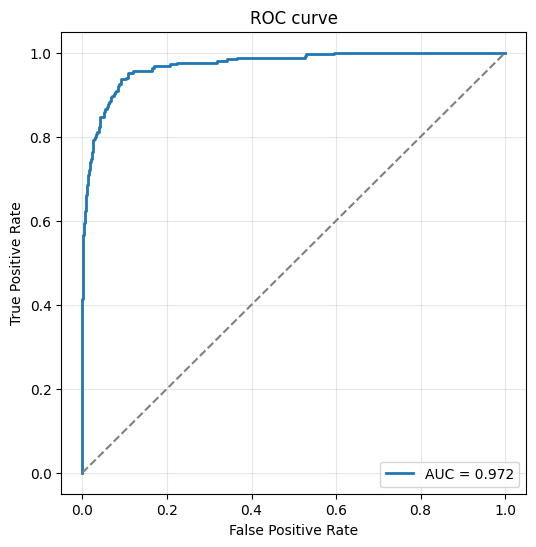

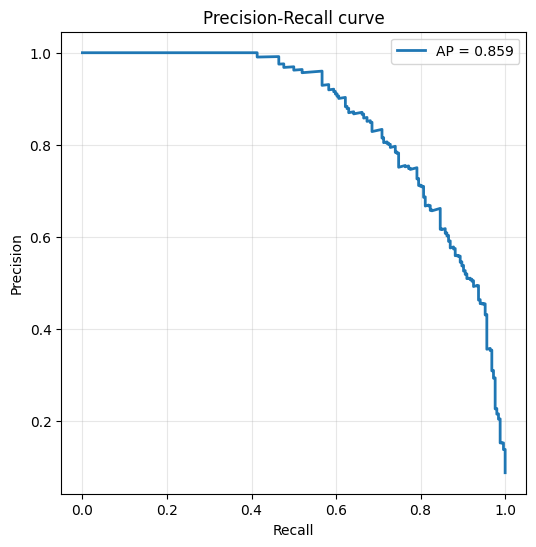

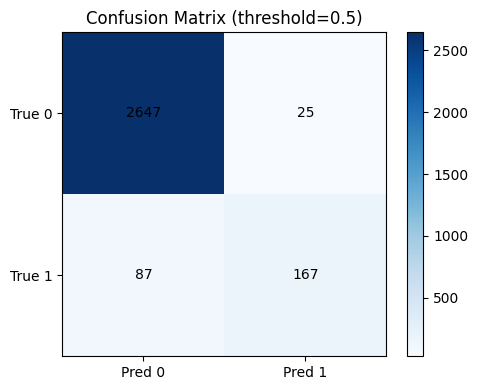

MAP: 100%|██████████| 1000/1000 [00:05<00:00, 190.39it/s, logpost=-291.8866, loglik=-291.8866, logprior=0.0000, ||grad||=0.0100, patience=0]


{'mean_auc': 0.9536274117917822, 'std_auc': 0.013168679371942943, 'min_auc': np.float64(0.9371012759170653), 'max_auc': np.float64(0.970957249070632), 'n_folds': 5}


In [9]:
geometry = EuclideanGeometry(d=2, D = diam)
alpha0 = model.inferred["MAP"]["final_params"]["alpha0"]
Z = model.inferred["MAP"]["final_params"]["Z"]
model = LatentSpaceModel(Y=Y, geometry=geometry, fixed_params={"Z": Z, "alpha0": alpha0})
inference = MAPInference(model, lr=lr_MAP)
result = inference.fit_multi_start(n_starts=n_starts_MAP, n_iter=n_iter_MAP, verbose=True, use_tqdm=True)

analysis = ModelAnalysis(model,inference_key="MAP")
analysis.plot_logposterior_trace()
analysis.compare_with_adjacency(analysis.P,title="Probability matrix")
analysis.internal_validation(n_sim=n_sim_iv)
analysis.plot_ppc_distributions()
analysis.laplacian_validation() 
analysis.binary_prediction_metrics()
analysis.plot_roc_curve()
analysis.plot_precision_recall_curve()
analysis.confusion_matrix(threshold=0.5)
analysis.cross_validation(n_folds=n_folds_cv, seed=seed_MAP, n_iter=n_iter_cv, lr=lr_MAP)
print(analysis.cross_validation_summary())

model.save("LesMiserables_R2_p.pkl")

### Model $\mathbb{R}^3$

#### Without weights

Multi_start (1)


MAP: 100%|██████████| 25000/25000 [02:01<00:00, 206.33it/s, logpost=-347.9408, loglik=-346.8596, logprior=-1.0812, ||grad||=0.0140, patience=0]



Best log-posterior: -347.9408


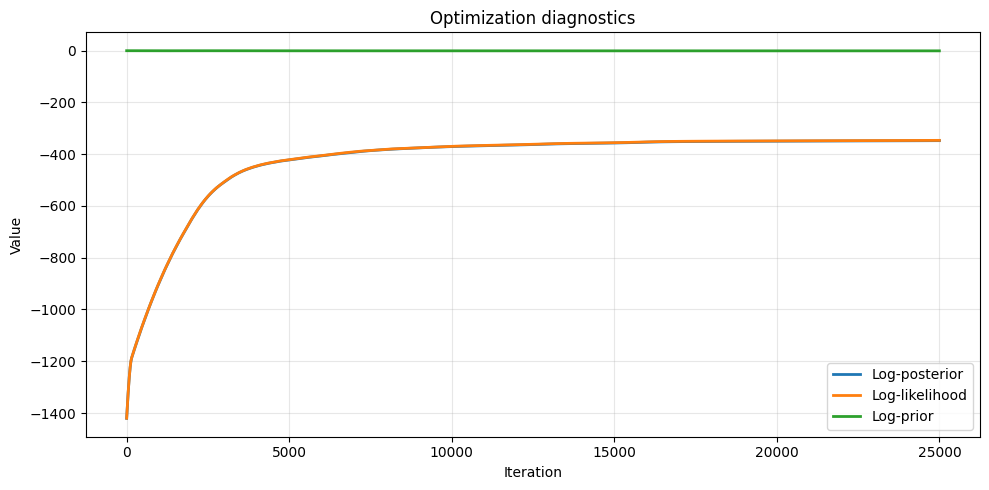

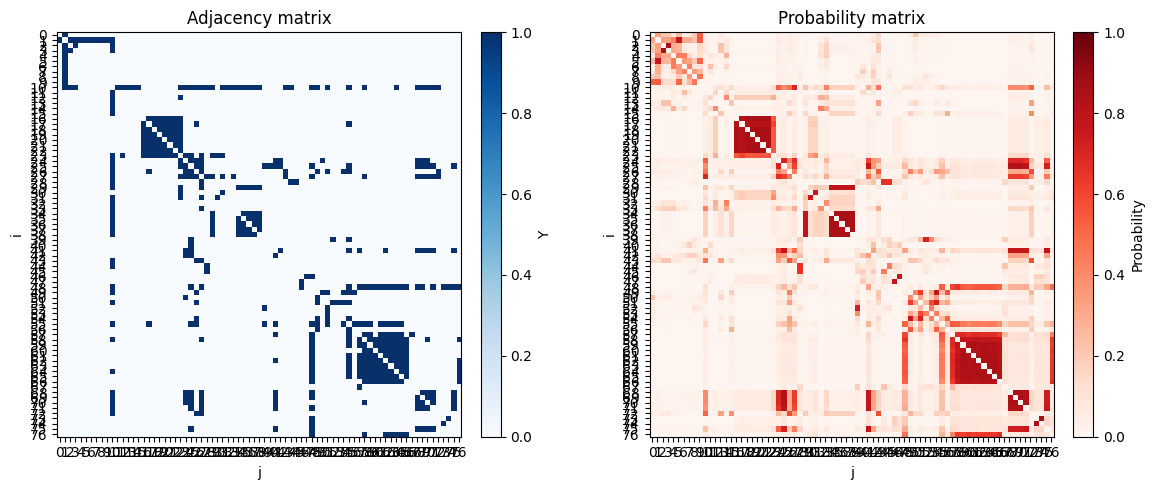

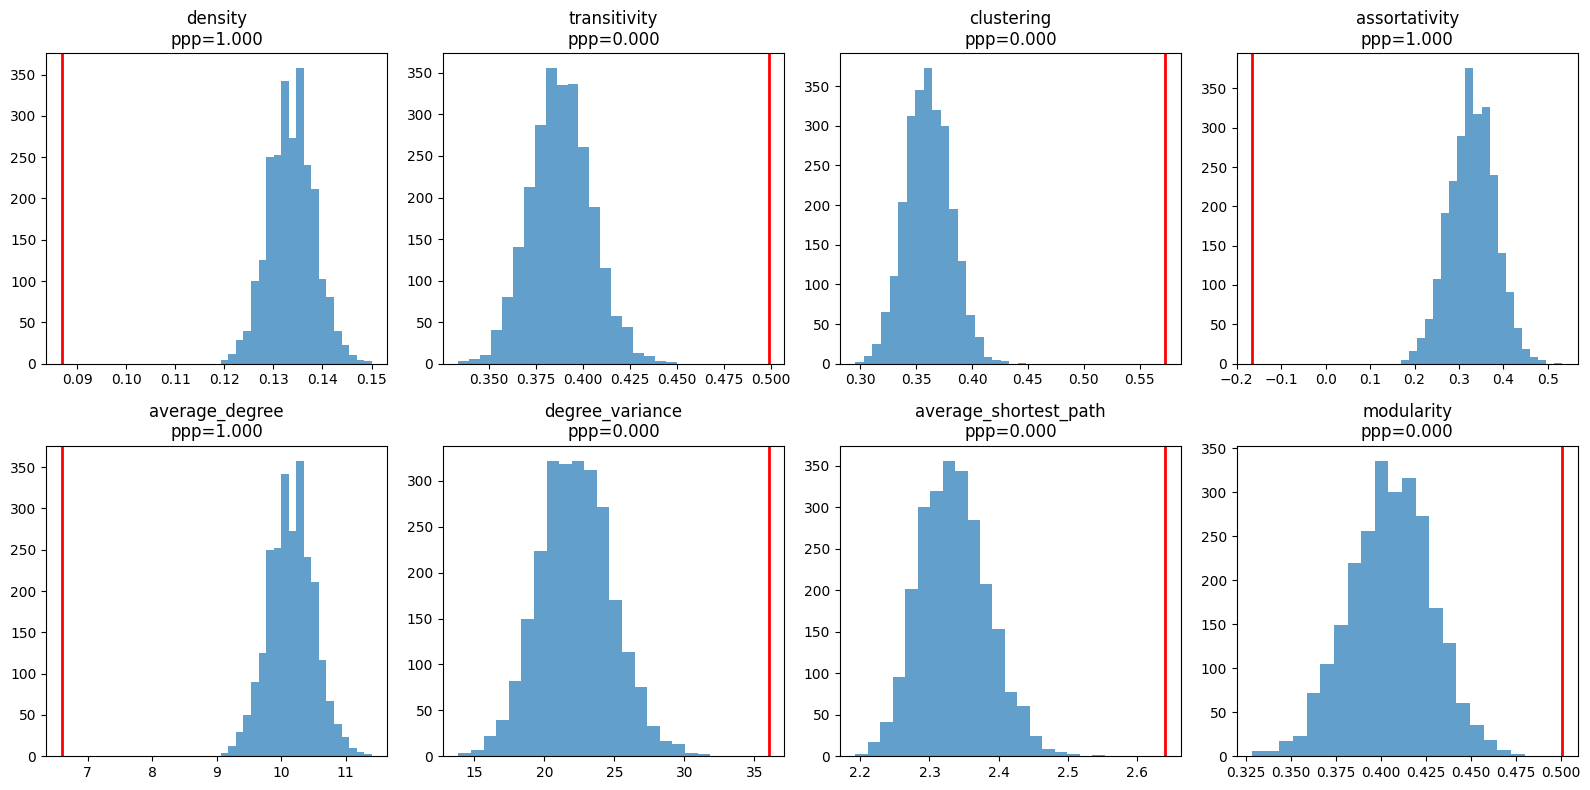

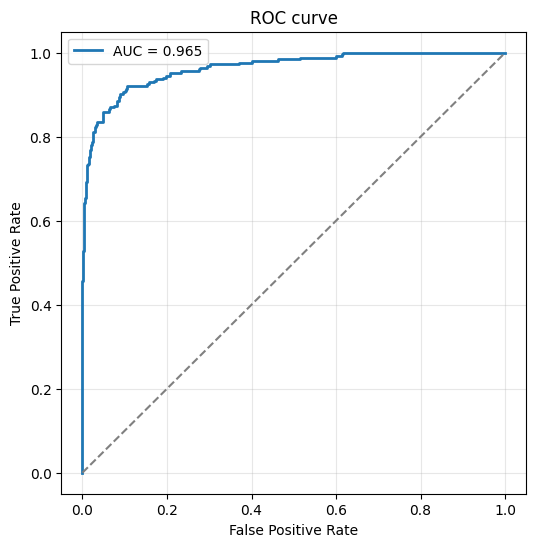

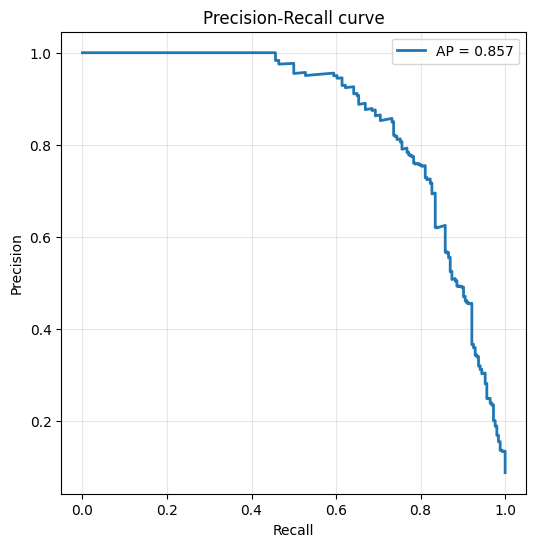

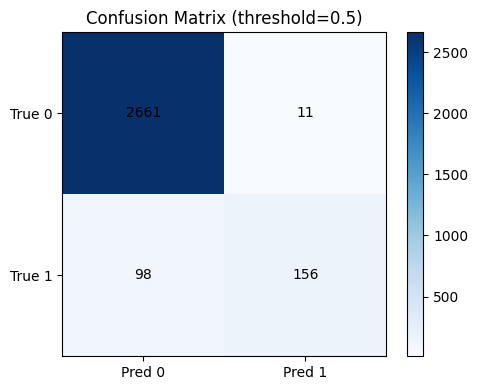

MAP: 100%|██████████| 1000/1000 [00:05<00:00, 183.18it/s, logpost=-268.7176, loglik=-267.6229, logprior=-1.0947, ||grad||=0.0140, patience=0]


{'mean_auc': 0.941084117699271, 'std_auc': 0.005062613495299712, 'min_auc': np.float64(0.935207336523126), 'max_auc': np.float64(0.9481926757889743), 'n_folds': 5}


In [10]:
geometry = EuclideanGeometry(d=3, D=diam)
model = LatentSpaceModel(Y=Y, geometry=geometry, fixed_params={"xi": np.ones(n)})
inference = MAPInference(model, lr=lr_MAP)
result = inference.fit_multi_start(n_starts=n_starts_MAP, n_iter=n_iter_MAP, verbose=True, use_tqdm=True)

analysis = ModelAnalysis(model,inference_key="MAP")
analysis.plot_logposterior_trace()
analysis.compare_with_adjacency(analysis.P,title="Probability matrix")
analysis.internal_validation(n_sim=n_sim_iv)
analysis.plot_ppc_distributions()
analysis.laplacian_validation() 
analysis.binary_prediction_metrics()
analysis.plot_roc_curve()
analysis.plot_precision_recall_curve()
analysis.confusion_matrix(threshold=0.5)
analysis.cross_validation(n_folds=n_folds_cv, seed=seed_MAP, n_iter=n_iter_cv, lr=lr_MAP)
print(analysis.cross_validation_summary())

model.save("LesMiserables_R3_c.pkl")

#### With weights

Multi_start (1)


MAP:  10%|▉         | 2380/25000 [00:07<01:14, 304.99it/s, logpost=-277.0760, loglik=-277.0760, logprior=0.0000, ||grad||=0.0100, patience=100]


[STOP] Early stopping at iter 2379 (no improvement in 101 steps)

Best log-posterior: -277.0760


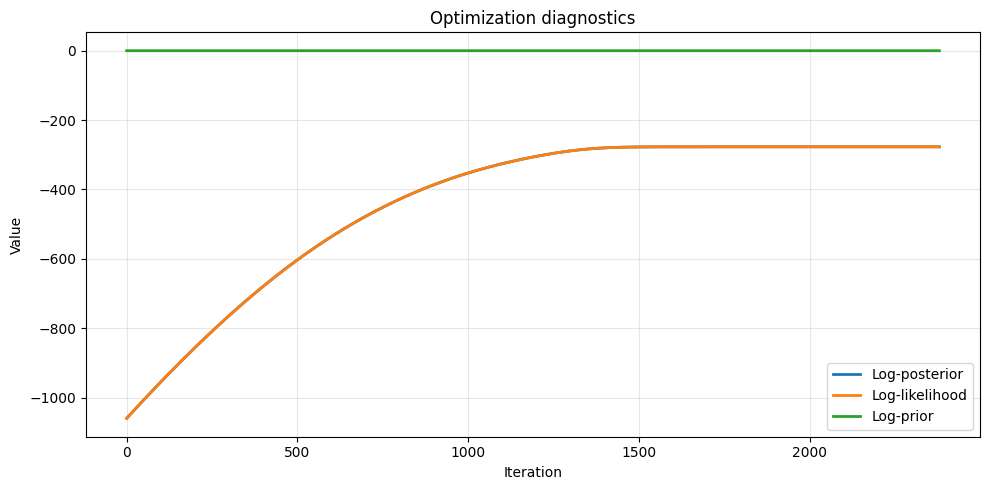

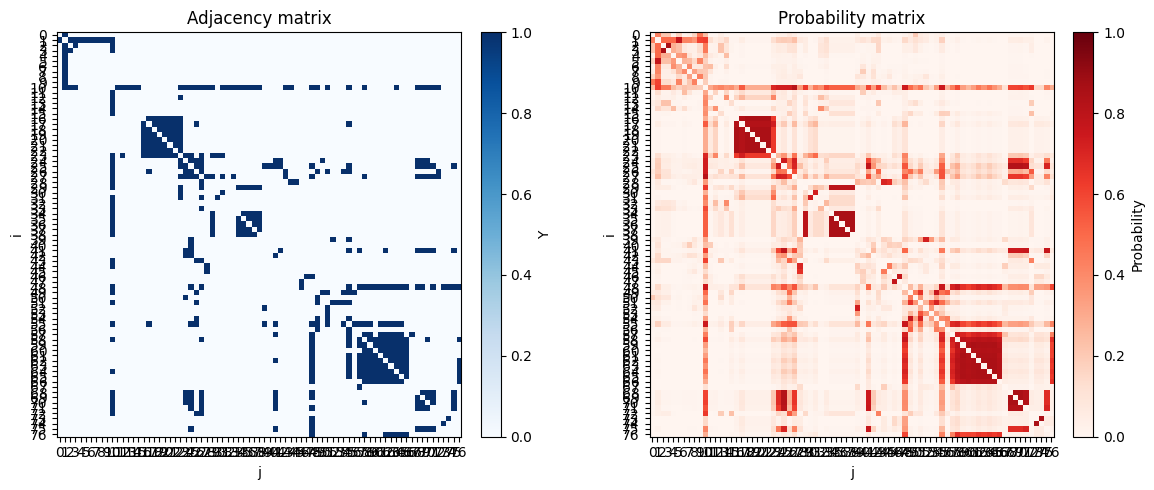

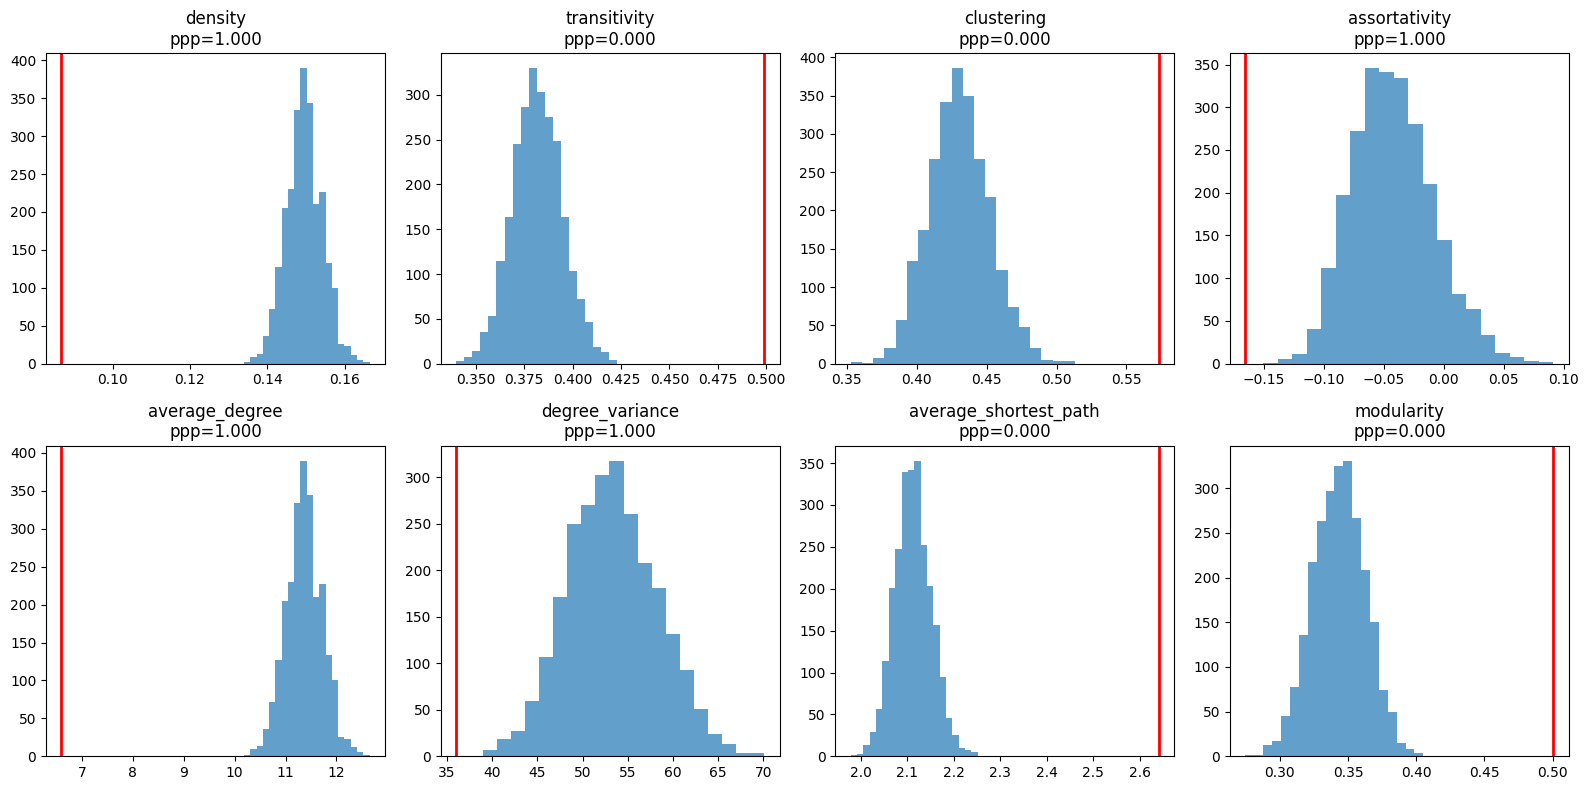

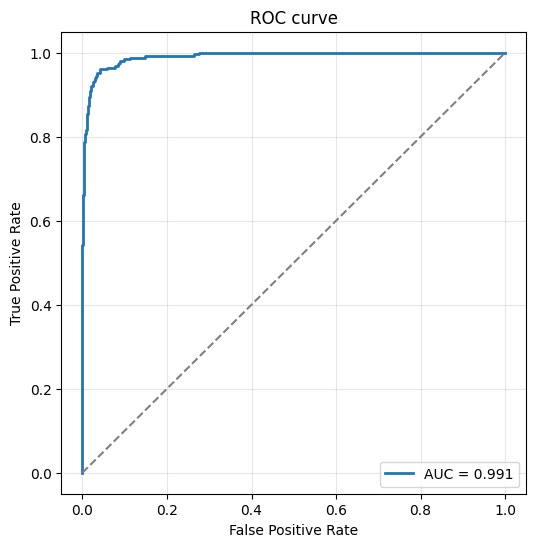

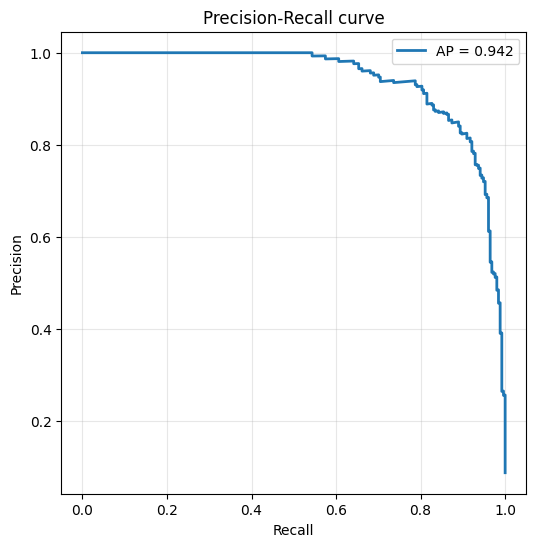

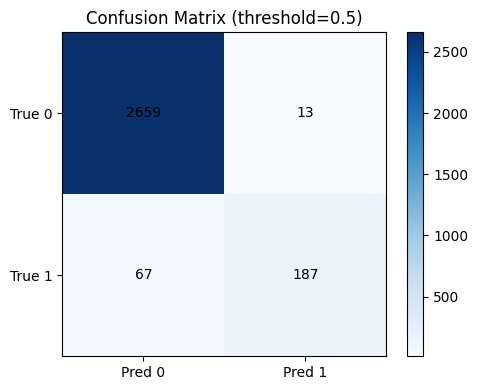

MAP:  46%|████▌     | 461/1000 [00:02<00:02, 201.74it/s, logpost=-218.1287, loglik=-218.1287, logprior=0.0000, ||grad||=0.0100, patience=49]


{'mean_auc': 0.9852415494737956, 'std_auc': 0.005308953201876946, 'min_auc': np.float64(0.9758812615955474), 'max_auc': np.float64(0.9912908452605995), 'n_folds': 5}


In [11]:
geometry = EuclideanGeometry(d=3, D = diam)
alpha0 = model.inferred["MAP"]["final_params"]["alpha0"]
Z = model.inferred["MAP"]["final_params"]["Z"]
model = LatentSpaceModel(Y=Y, geometry=geometry, fixed_params={"Z": Z, "alpha0": alpha0})
inference = MAPInference(model, lr=lr_MAP)
result = inference.fit_multi_start(n_starts=n_starts_MAP, n_iter=n_iter_MAP, verbose=True, use_tqdm=True)

analysis = ModelAnalysis(model,inference_key="MAP")
analysis.plot_logposterior_trace()
analysis.compare_with_adjacency(analysis.P,title="Probability matrix")
analysis.internal_validation(n_sim=n_sim_iv)
analysis.plot_ppc_distributions()
analysis.laplacian_validation() 
analysis.binary_prediction_metrics()
analysis.plot_roc_curve()
analysis.plot_precision_recall_curve()
analysis.confusion_matrix(threshold=0.5)
analysis.cross_validation(n_folds=n_folds_cv, seed=seed_MAP, n_iter=n_iter_cv, lr=lr_MAP)
print(analysis.cross_validation_summary())

model.save("LesMiserables_R3_p.pkl")

## Models over $\mathbb{S}^d$

### Model $\mathbb{S}^1$

#### Without weights

Multi_start (1)


MAP:  42%|████▏     | 10527/25000 [01:39<02:16, 105.86it/s, logpost=-592.7772, loglik=-592.2263, logprior=-0.5509, ||grad||=0.0140, patience=100]


[STOP] Early stopping at iter 10526 (no improvement in 101 steps)

Best log-posterior: -592.7772


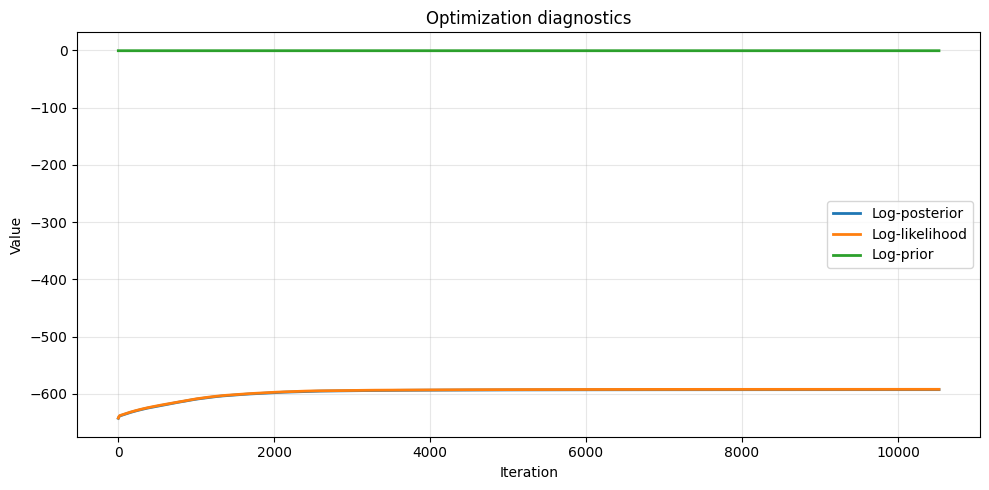

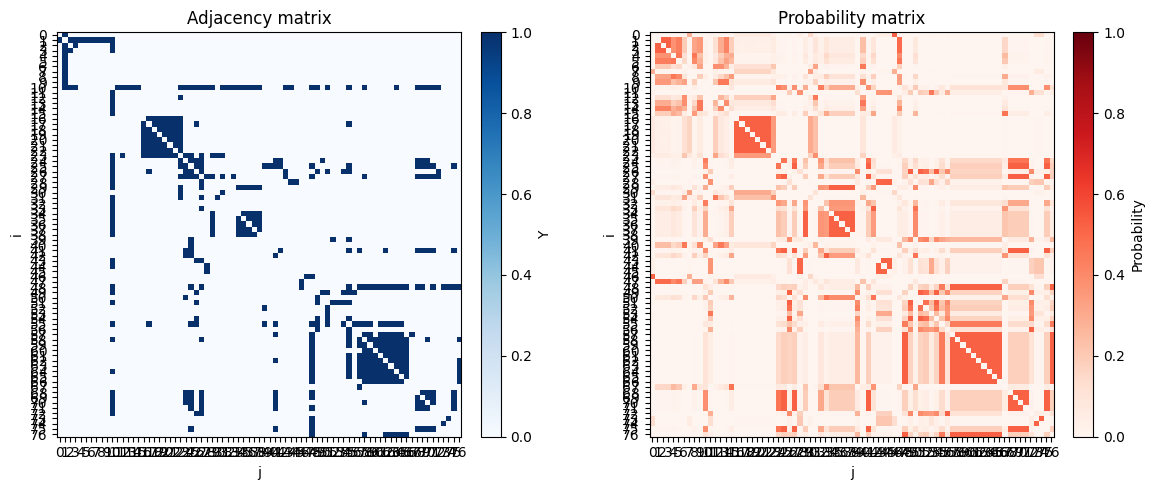

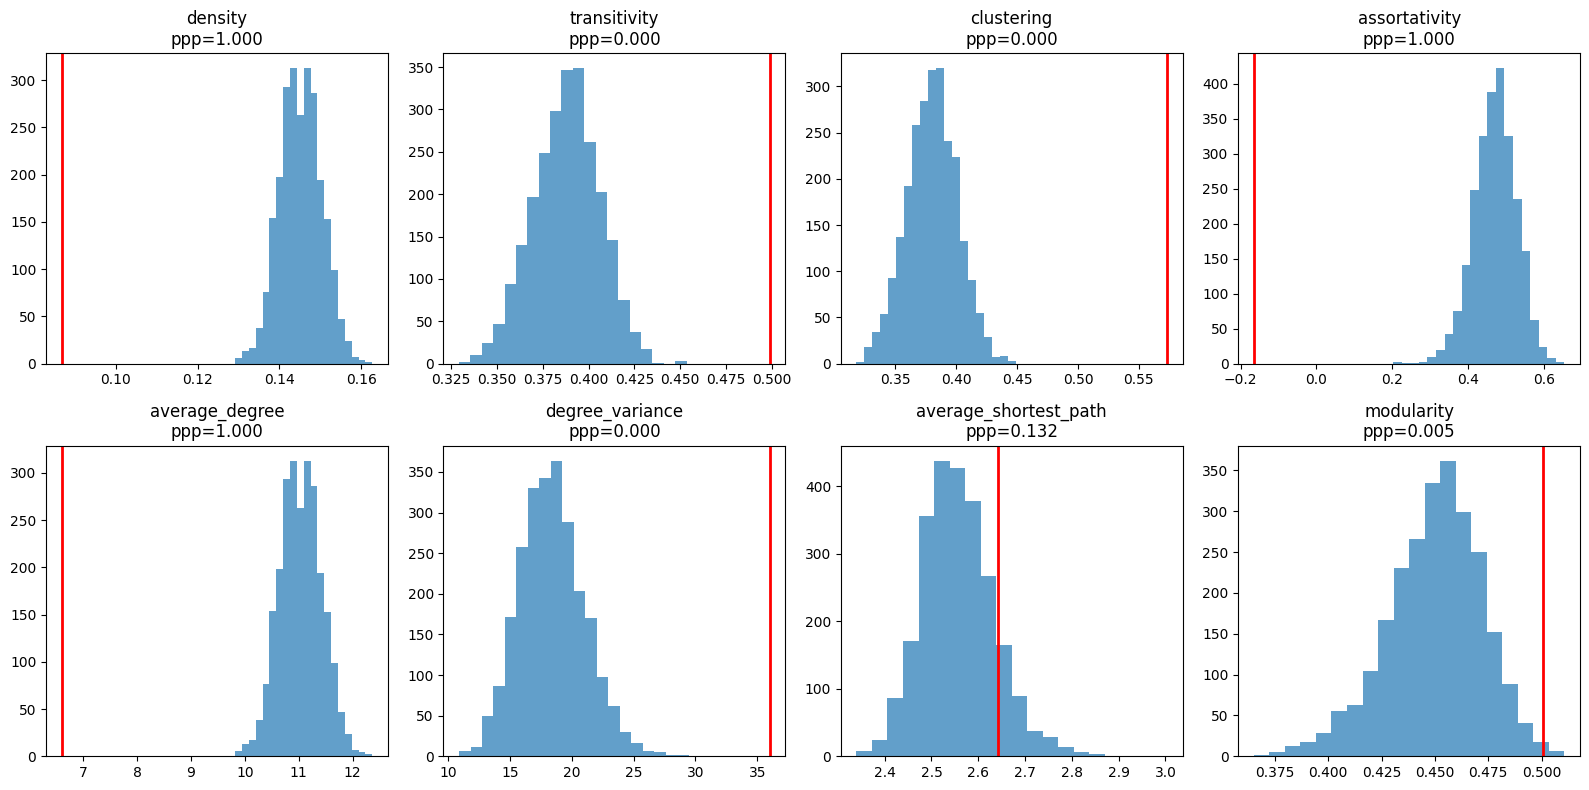

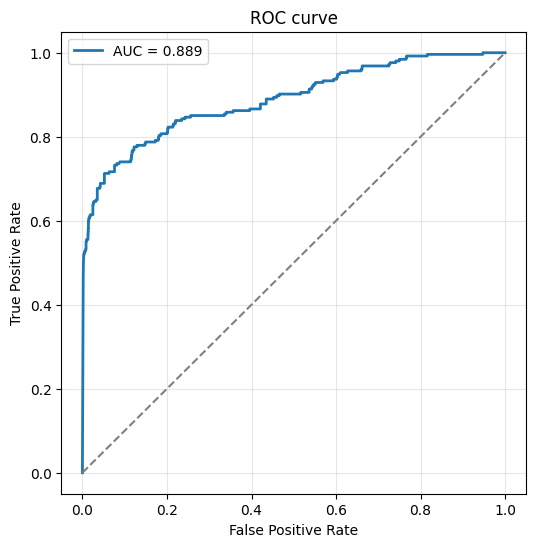

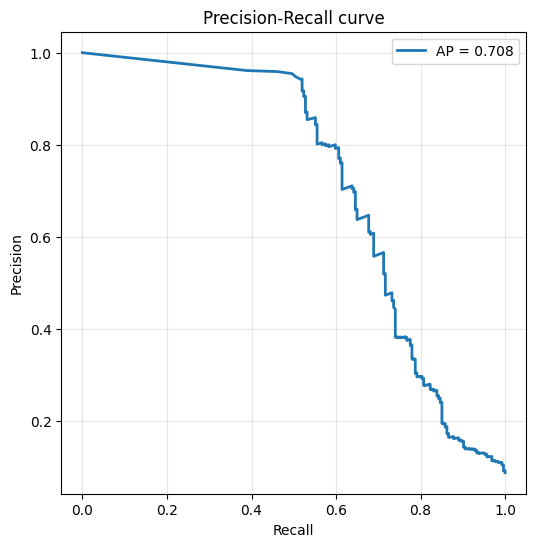

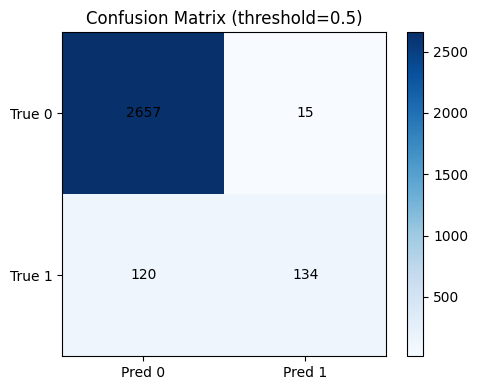

MAP: 100%|██████████| 1000/1000 [00:16<00:00, 62.18it/s, logpost=-455.7614, loglik=-455.2112, logprior=-0.5502, ||grad||=0.0140, patience=0]


{'mean_auc': 0.8765000650175712, 'std_auc': 0.020858408784748463, 'min_auc': np.float64(0.8465410685805422), 'max_auc': np.float64(0.9087864002478315), 'n_folds': 5}


In [12]:
geometry = SphericalGeometry(d=1, D=diam)
with open("LesMiserables_R2_c.pkl", "rb") as f:
    results_R2_c = pickle.load(f)
Z_init = np.zeros((n,2))
Z_init[:,:] = np.asarray(results_R2_c['latent_params']['Z'])
for i in range(n):
    Z_init[i] = geometry.project_to_domain(Z_init[i])
model = LatentSpaceModel(Y=Y, geometry=geometry, fixed_params={"xi": np.ones(n)})
inference = MAPInference(model, lr=lr_MAP)
result = inference.fit_multi_start(n_starts=n_starts_MAP, n_iter=n_iter_MAP, verbose=True, use_tqdm=True, init_params = {"alpha0":0.0,"Z": Z_init})

analysis = ModelAnalysis(model,inference_key="MAP")
analysis.plot_logposterior_trace()
analysis.compare_with_adjacency(analysis.P,title="Probability matrix")
analysis.internal_validation(n_sim=n_sim_iv)
analysis.plot_ppc_distributions()
analysis.laplacian_validation() 
analysis.binary_prediction_metrics()
analysis.plot_roc_curve()
analysis.plot_precision_recall_curve()
analysis.confusion_matrix(threshold=0.5)
analysis.cross_validation(n_folds=n_folds_cv, seed=seed_MAP, n_iter=n_iter_cv, lr=lr_MAP)
print(analysis.cross_validation_summary())

model.save("LesMiserables_S1_c.pkl")

alpha0 = model.inferred["MAP"]["final_params"]["alpha0"]
Z = model.inferred["MAP"]["final_params"]["Z"]

#### With weights

Multi_start (1)


MAP:  35%|███▍      | 8723/25000 [01:27<02:42, 100.23it/s, logpost=-450.1552, loglik=-450.1552, logprior=0.0000, ||grad||=0.0100, patience=100]


[STOP] Early stopping at iter 8722 (no improvement in 101 steps)

Best log-posterior: -450.1552


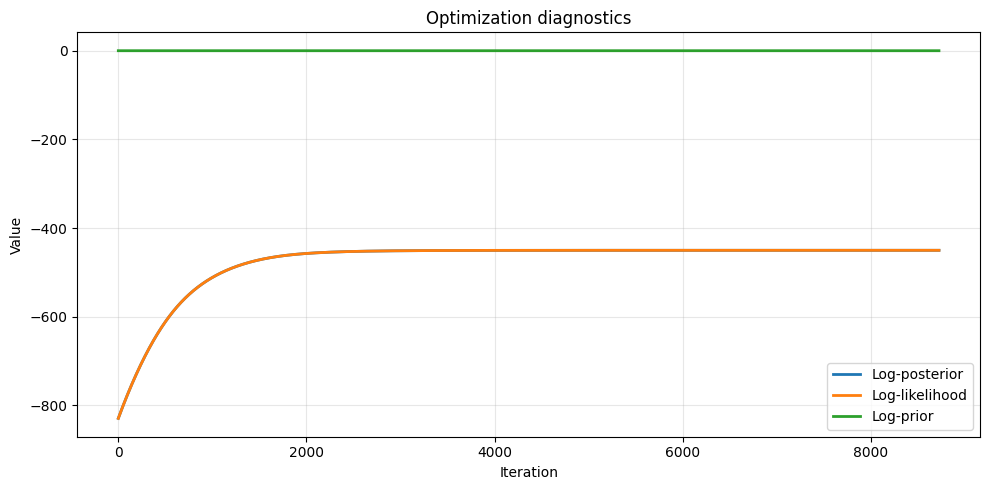

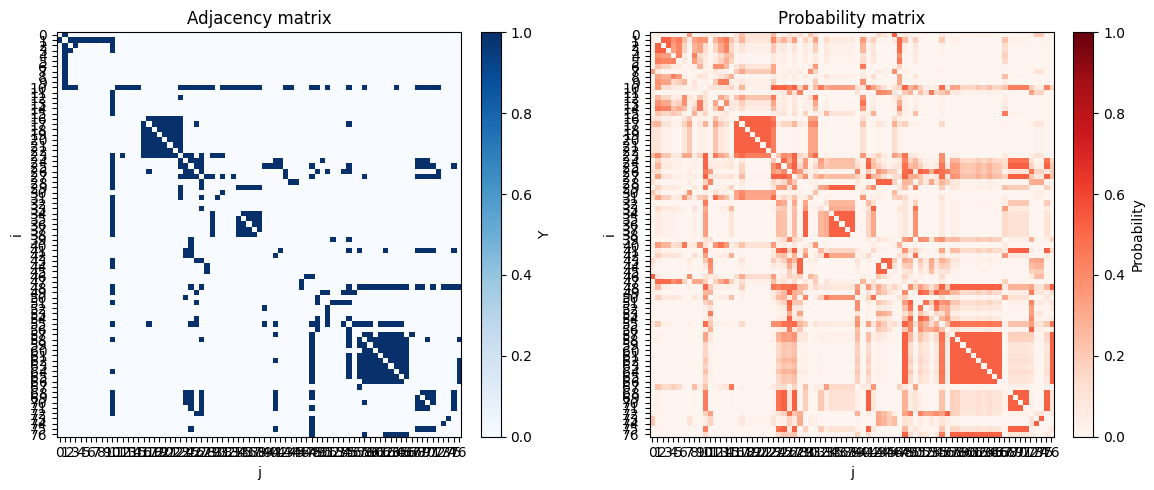

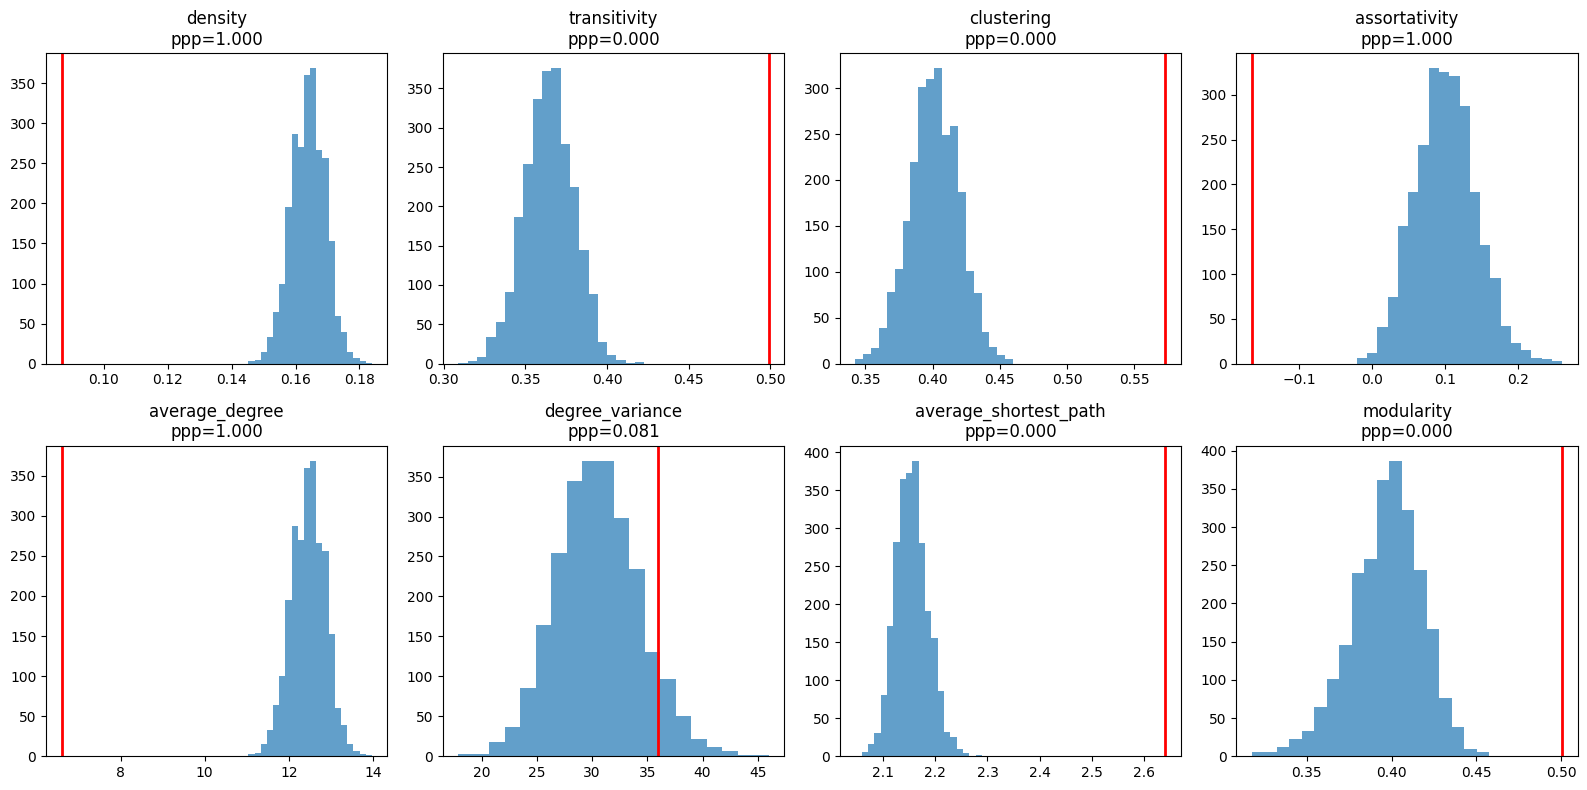

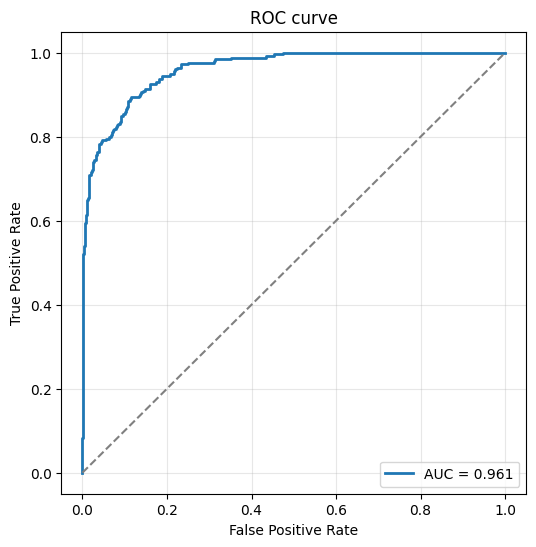

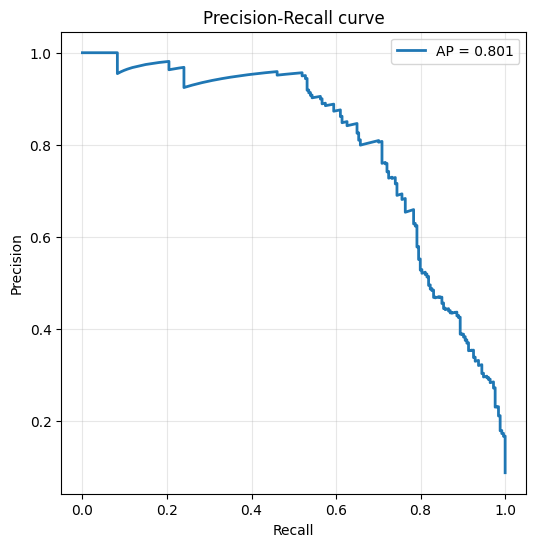

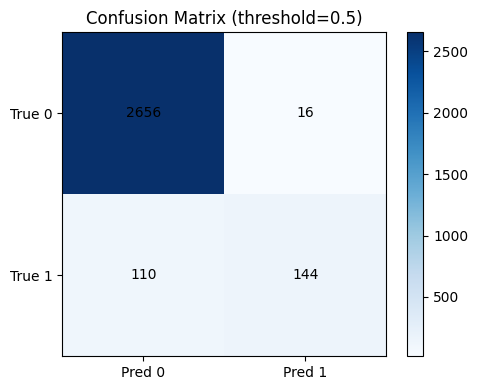

MAP: 100%|██████████| 1000/1000 [00:10<00:00, 96.37it/s, logpost=-353.5283, loglik=-353.5283, logprior=0.0000, ||grad||=0.0100, patience=0]


{'mean_auc': 0.9439385194767123, 'std_auc': 0.009670865789317641, 'min_auc': np.float64(0.9302565124933545), 'max_auc': np.float64(0.956435873605948), 'n_folds': 5}


In [13]:
geometry = SphericalGeometry(d=1, D=diam)
model = LatentSpaceModel(Y=Y, geometry=geometry, fixed_params={"Z": Z, "alpha0": alpha0})
inference = MAPInference(model, lr=lr_MAP)
result = inference.fit_multi_start(n_starts=n_starts_MAP, n_iter=n_iter_MAP, verbose=True, use_tqdm=True)

analysis = ModelAnalysis(model,inference_key="MAP")
analysis.plot_logposterior_trace()
analysis.compare_with_adjacency(analysis.P,title="Probability matrix")
analysis.internal_validation(n_sim=n_sim_iv)
analysis.plot_ppc_distributions()
analysis.laplacian_validation() 
analysis.binary_prediction_metrics()
analysis.plot_roc_curve()
analysis.plot_precision_recall_curve()
analysis.confusion_matrix(threshold=0.5)
analysis.cross_validation(n_folds=n_folds_cv, seed=seed_MAP, n_iter=n_iter_cv, lr=lr_MAP)
print(analysis.cross_validation_summary())

model.save("LesMiserables_S1_p.pkl")

### Model $\mathbb{S}^2$

#### Without weights

In [14]:
with open("LesMiserables_R3_p.pkl", "rb") as f:
    results_R3_p = pickle.load(f)

Z_init = np.zeros((n,3))
Z_init[:,:] = np.asarray(results_R3_p['latent_params']['Z'])

Multi_start (1)


MAP: 100%|██████████| 25000/25000 [05:33<00:00, 74.88it/s, logpost=-419.1848, loglik=-418.5181, logprior=-0.6667, ||grad||=0.0140, patience=7]  



Best log-posterior: -419.1848


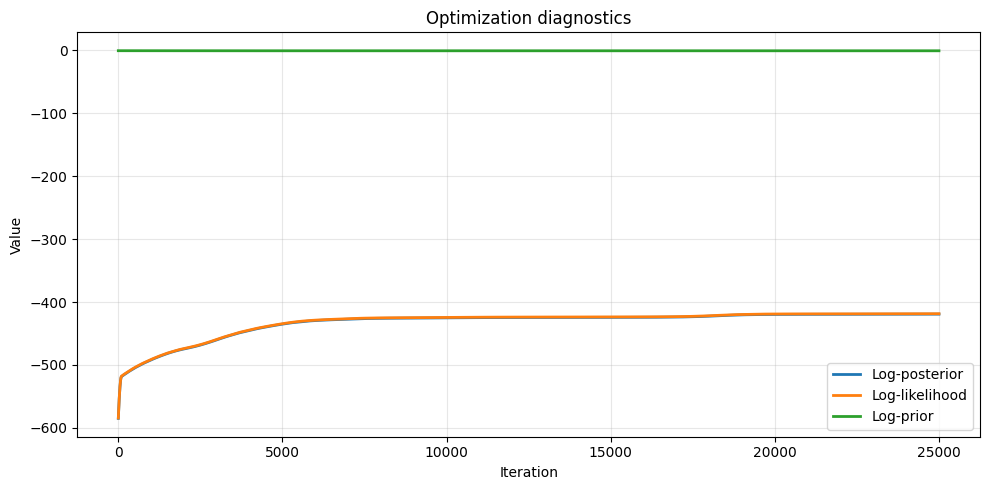

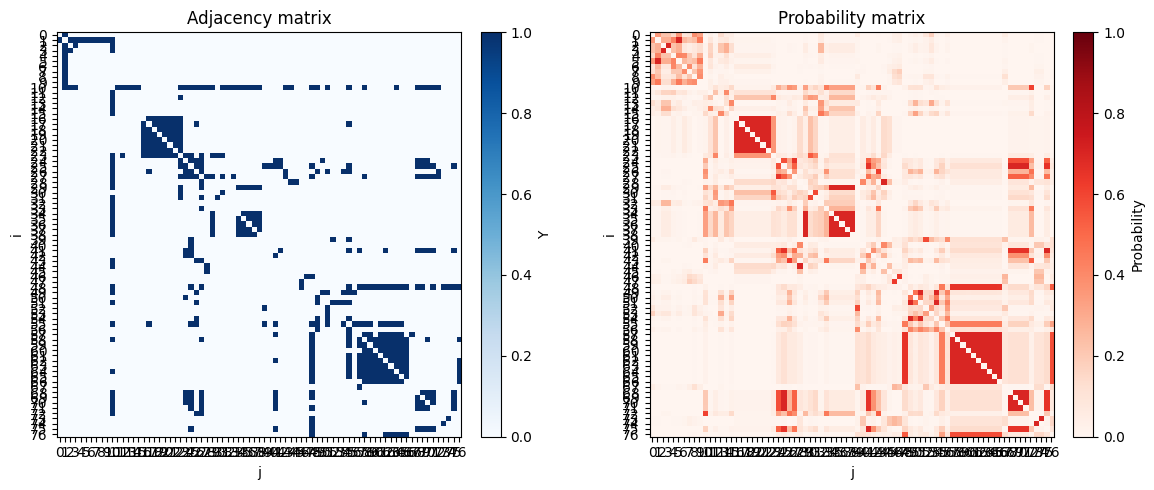

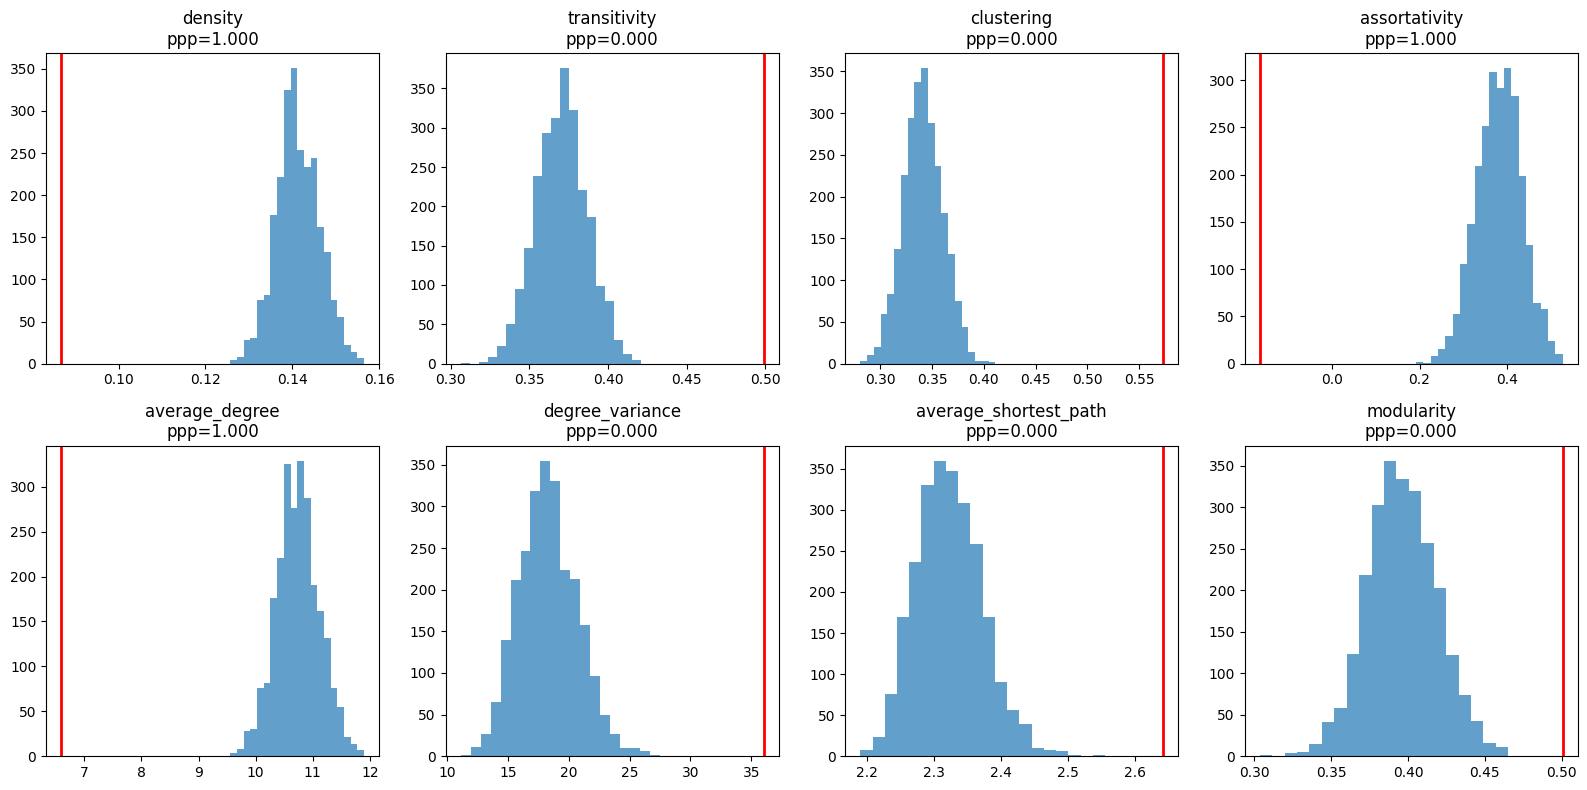

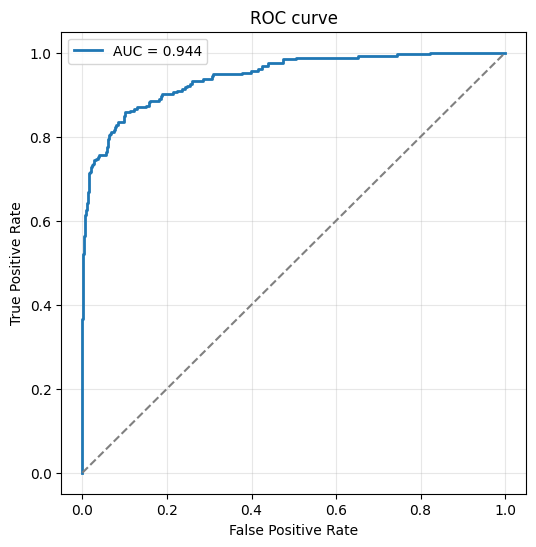

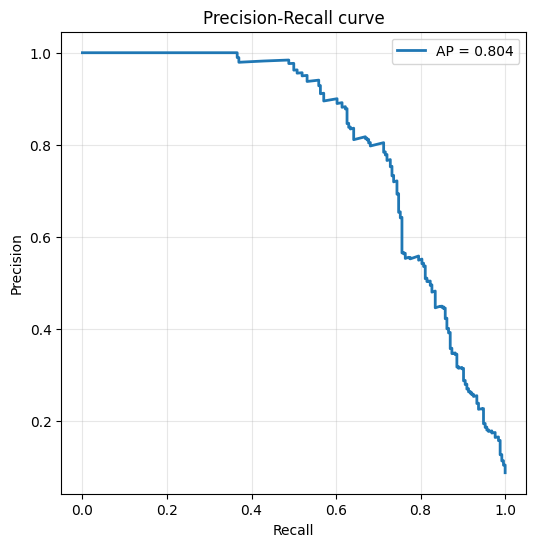

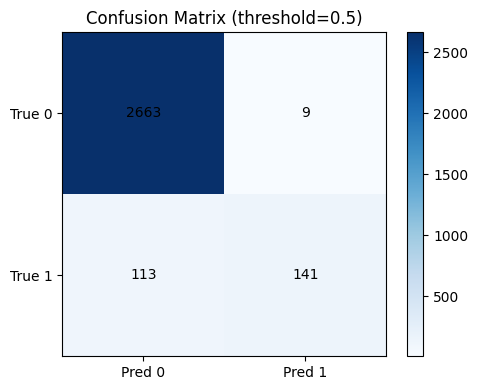

MAP: 100%|██████████| 1000/1000 [00:06<00:00, 162.49it/s, logpost=-325.5399, loglik=-324.8691, logprior=-0.6707, ||grad||=0.0140, patience=0]


{'mean_auc': 0.9187368072117554, 'std_auc': 0.006075431045689112, 'min_auc': np.float64(0.9084078146009649), 'max_auc': np.float64(0.9251282743721306), 'n_folds': 5}


In [15]:
geometry = SphericalGeometry(d=2, D=diam)
model = LatentSpaceModel(Y=Y, geometry=geometry, fixed_params={"xi": np.ones(n)})
inference = MAPInference(model, lr=lr_MAP)
result = inference.fit_multi_start(n_starts=n_starts_MAP, n_iter=n_iter_MAP, verbose=True, use_tqdm=True, init_params = {"alpha0":0.0,"Z": Z_init})

analysis = ModelAnalysis(model,inference_key="MAP")
analysis.plot_logposterior_trace()
analysis.compare_with_adjacency(analysis.P,title="Probability matrix")
analysis.internal_validation(n_sim=n_sim_iv)
analysis.plot_ppc_distributions()
analysis.laplacian_validation() 
analysis.binary_prediction_metrics()
analysis.plot_roc_curve()
analysis.plot_precision_recall_curve()
analysis.confusion_matrix(threshold=0.5)
analysis.cross_validation(n_folds=n_folds_cv, seed=seed_MAP, n_iter=n_iter_cv, lr=lr_MAP)
print(analysis.cross_validation_summary())

model.save("LesMiserables_S2_c.pkl")


alpha0 = model.inferred["MAP"]["final_params"]["alpha0"]
Z = model.inferred["MAP"]["final_params"]["Z"]

#### With weights

Multi_start (1)


MAP:  14%|█▍        | 3514/25000 [00:12<01:15, 282.75it/s, logpost=-334.8519, loglik=-334.8519, logprior=0.0000, ||grad||=0.0100, patience=100]


[STOP] Early stopping at iter 3513 (no improvement in 101 steps)

Best log-posterior: -334.8519


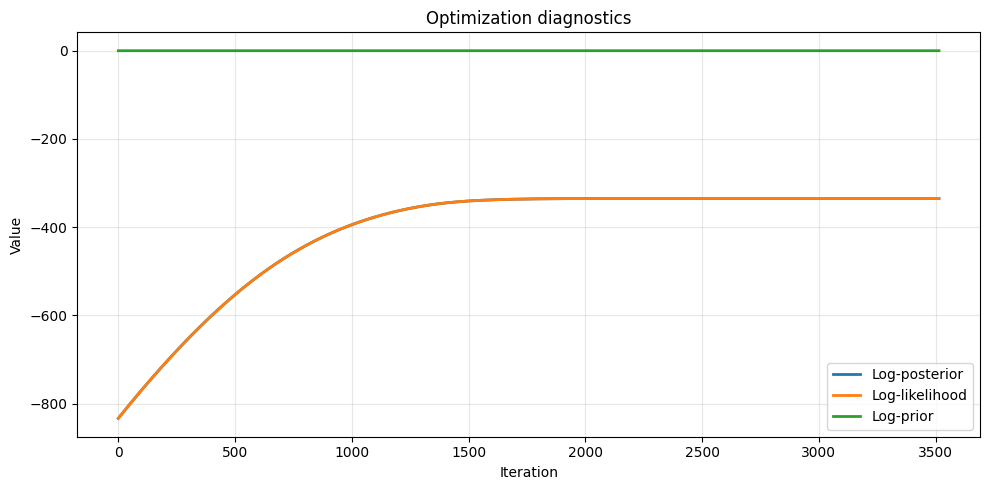

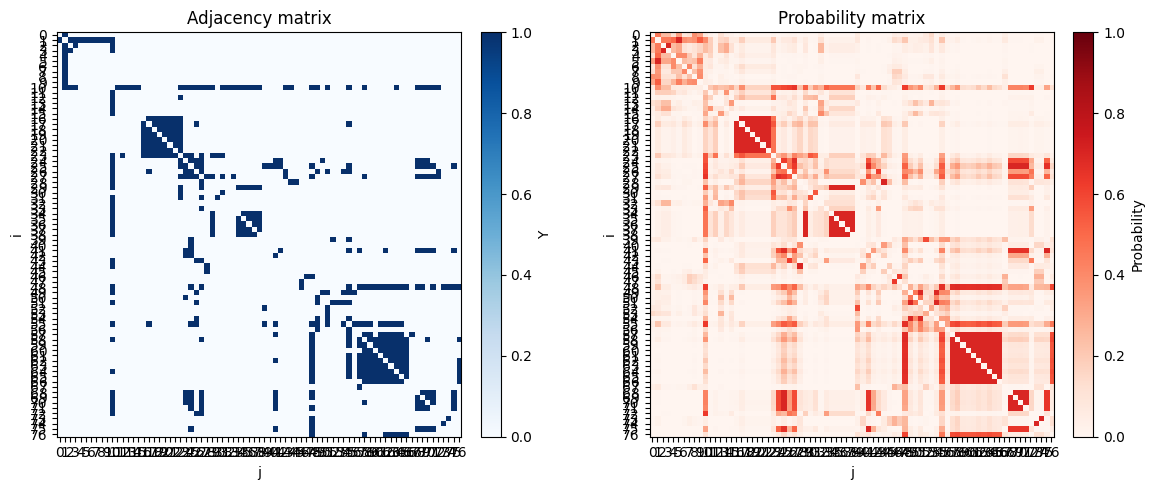

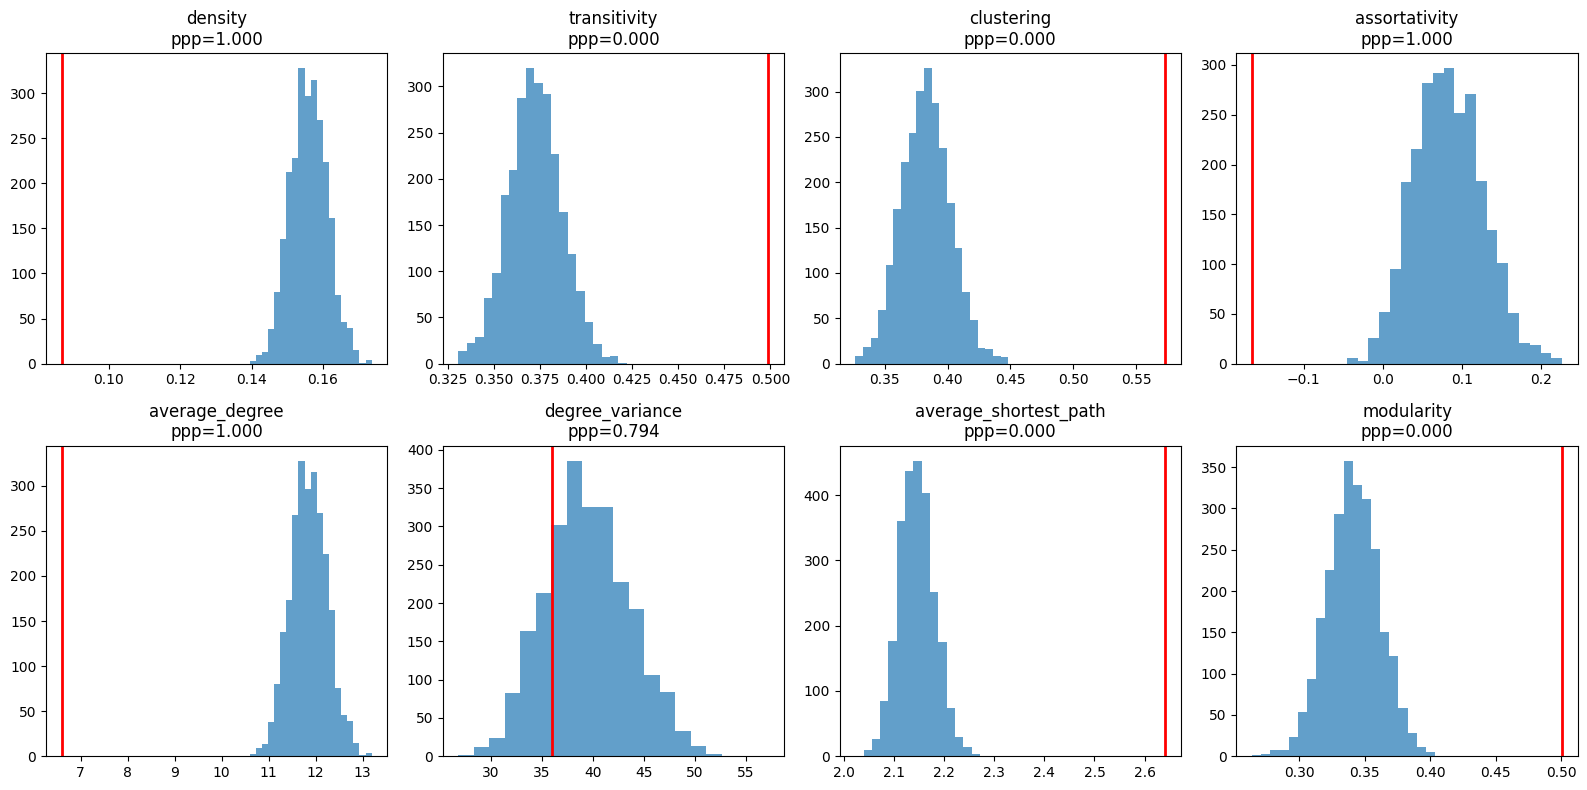

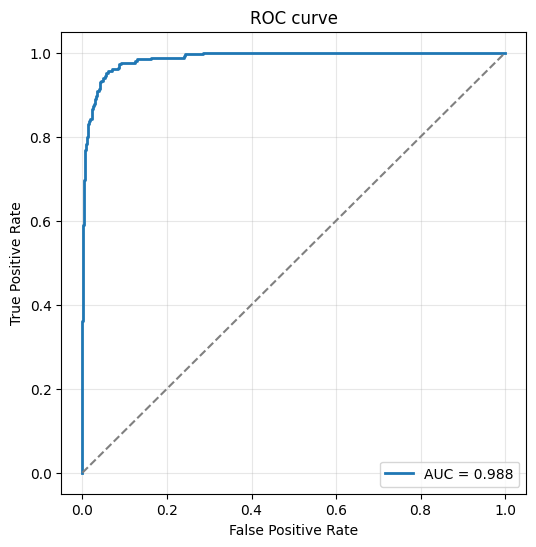

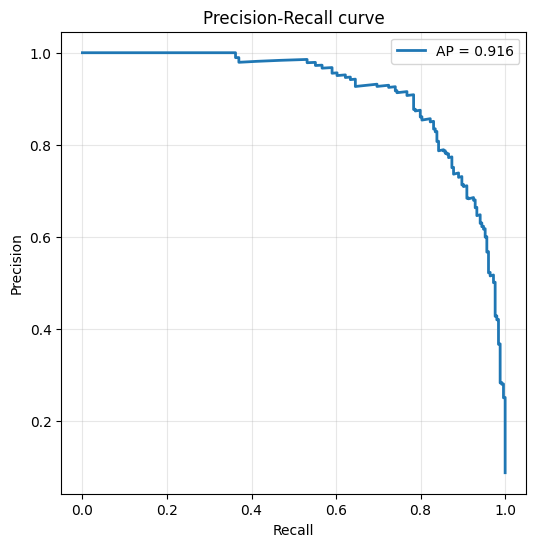

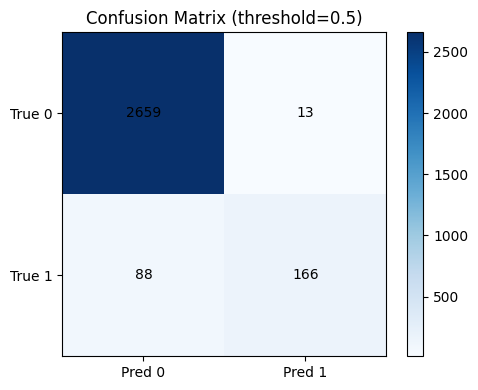

MAP: 100%|██████████| 1000/1000 [00:04<00:00, 249.07it/s, logpost=-261.1093, loglik=-261.1093, logprior=0.0000, ||grad||=0.0100, patience=2]


{'mean_auc': 0.9790504109564345, 'std_auc': 0.003913071361952192, 'min_auc': np.float64(0.9723723481487456), 'max_auc': np.float64(0.9836956521739131), 'n_folds': 5}


In [16]:
geometry = SphericalGeometry(d=2, D=diam)
model = LatentSpaceModel(Y=Y, geometry=geometry, fixed_params={"Z": Z, "alpha0": alpha0})
inference = MAPInference(model, lr=lr_MAP)
result = inference.fit_multi_start(n_starts=n_starts_MAP, n_iter=n_iter_MAP, verbose=True, use_tqdm=True)

analysis = ModelAnalysis(model,inference_key="MAP")
analysis.plot_logposterior_trace()
analysis.compare_with_adjacency(analysis.P,title="Probability matrix")
analysis.internal_validation(n_sim=n_sim_iv)
analysis.plot_ppc_distributions()
analysis.laplacian_validation() 
analysis.binary_prediction_metrics()
analysis.plot_roc_curve()
analysis.plot_precision_recall_curve()
analysis.confusion_matrix(threshold=0.5)
analysis.cross_validation(n_folds=n_folds_cv, seed=seed_MAP, n_iter=n_iter_cv, lr=lr_MAP)
print(analysis.cross_validation_summary())

model.save("LesMiserables_S2_p.pkl")

## Models over $\mathbb{H}^d$

### Model $\mathbb{H}^1$

#### Without weights

In [17]:
with open("LesMiserables_R1_c.pkl", "rb") as f:
    results_R1_c = pickle.load(f)

Z_init = np.zeros((n,2))
Z_init[:,0:1] = np.asarray(results_R1_c['latent_params']['Z'])
for i in range(n):
    Z_init[i] = geometry.project_to_domain(Z_init[i])

Multi_start (1)


MAP:  16%|█▌        | 3887/25000 [00:21<01:57, 179.74it/s, logpost=-860.7632, loglik=-860.0244, logprior=-0.7388, ||grad||=0.0140, patience=100]


[STOP] Early stopping at iter 3886 (no improvement in 101 steps)

Best log-posterior: -860.7632


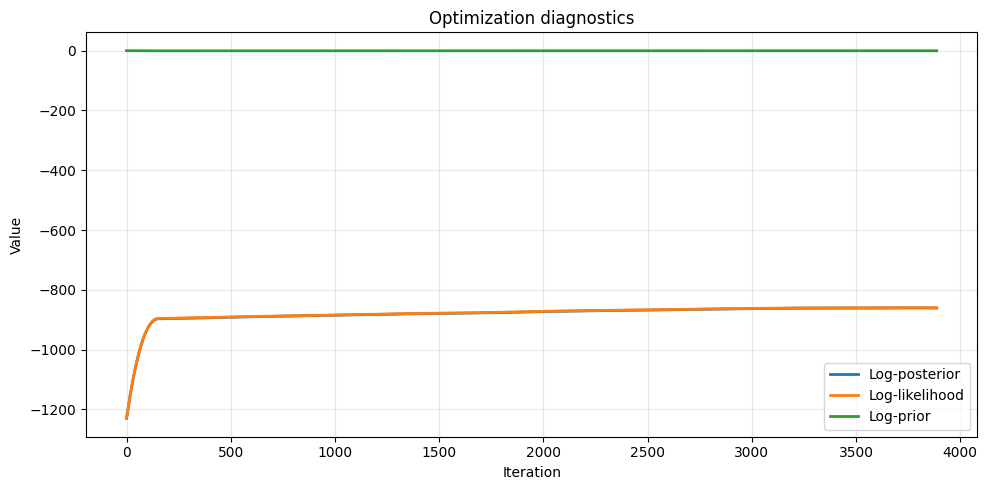

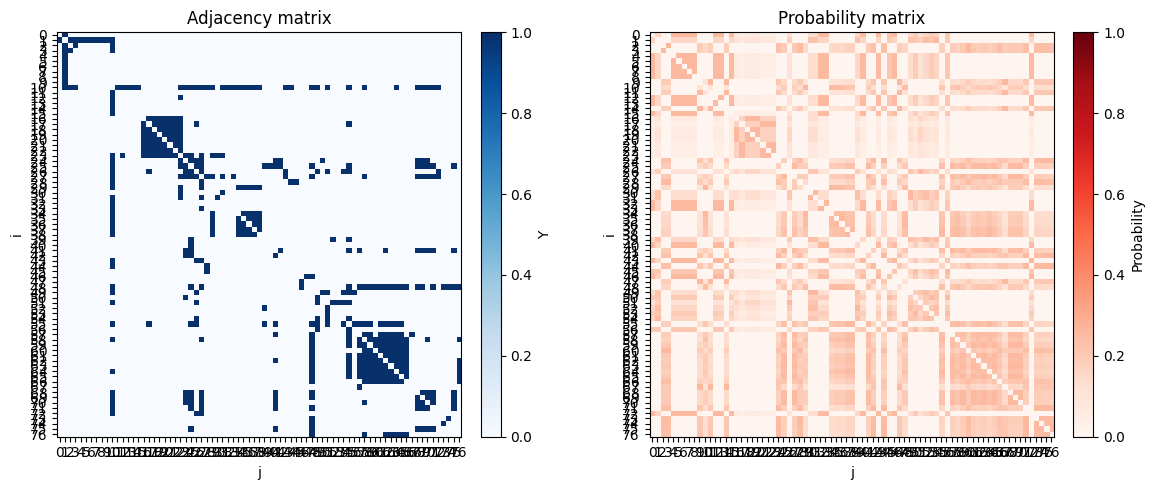

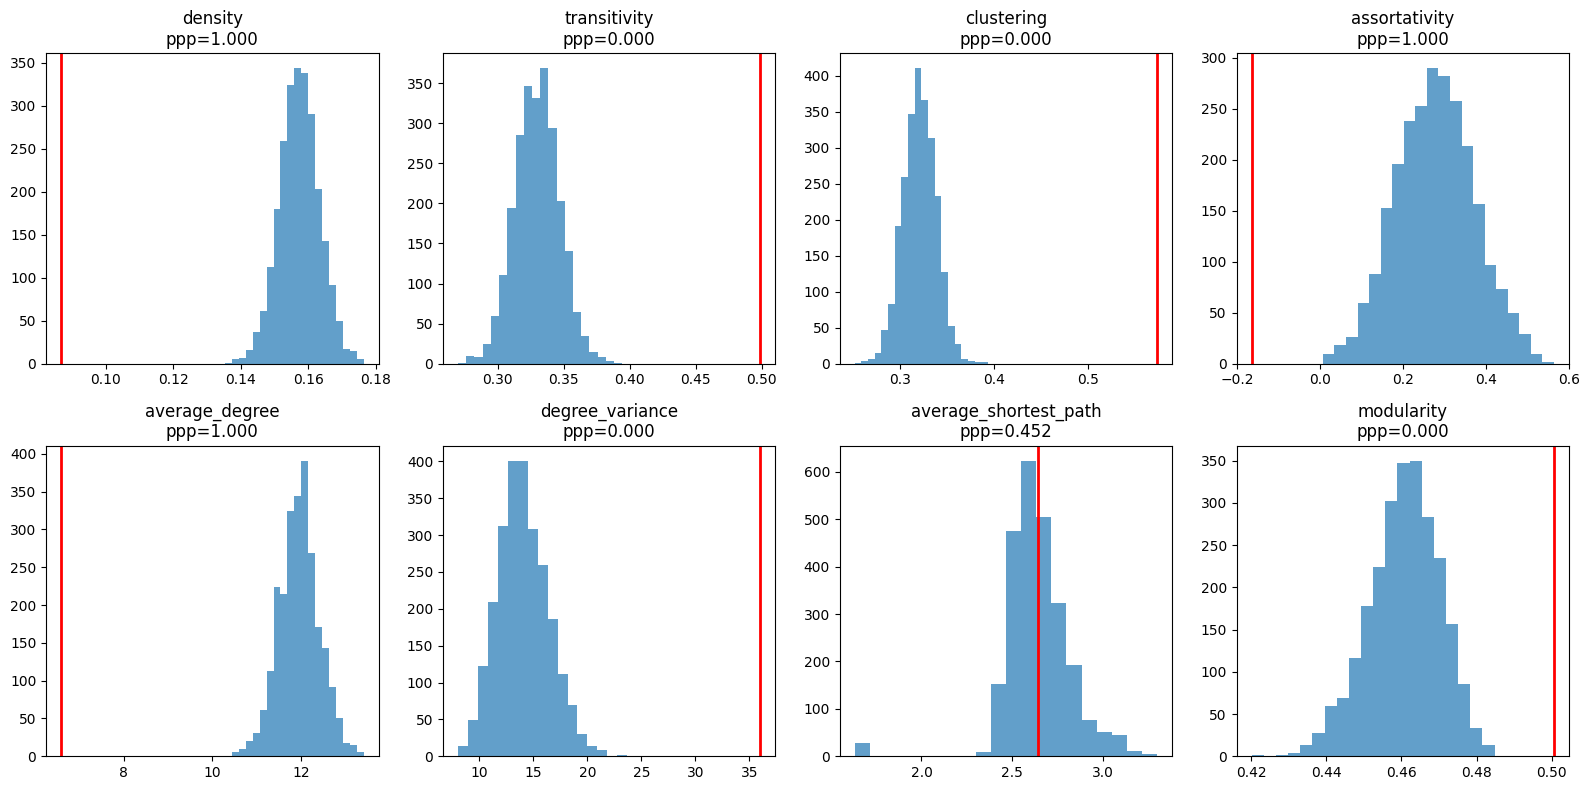

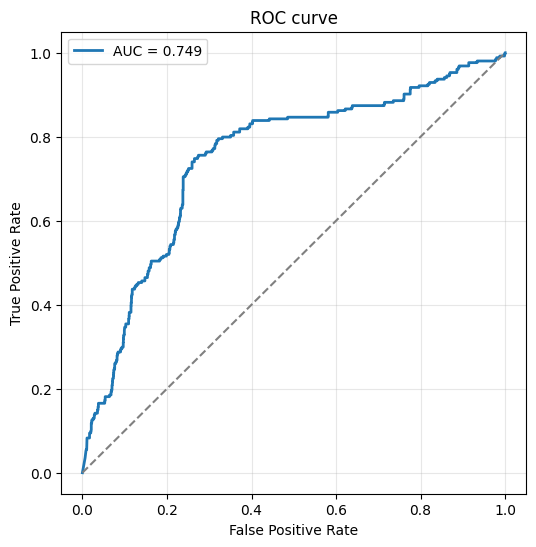

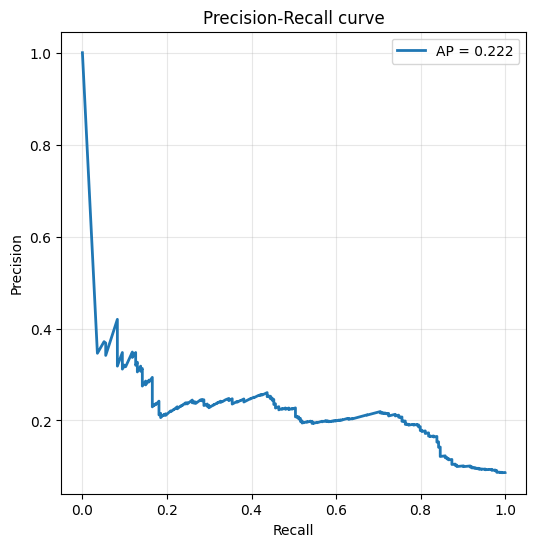

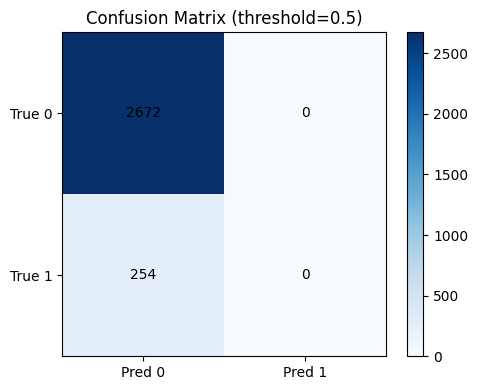

MAP:   5%|▌         | 52/1000 [00:01<00:24, 38.11it/s, logpost=-665.0552, loglik=-664.3079, logprior=-0.7473, ||grad||=0.0141, patience=49]


{'mean_auc': 0.7483461174547934, 'std_auc': 0.023607749919862062, 'min_auc': np.float64(0.7166486632460167), 'max_auc': np.float64(0.7875631313131313), 'n_folds': 5}


In [18]:
geometry = HyperbolicGeometry(d=1, D=diam)
model = LatentSpaceModel(Y=Y, geometry=geometry, fixed_params={"xi": np.ones(n)})
inference = MAPInference(model, lr=lr_MAP)
result = inference.fit_multi_start(n_starts=n_starts_MAP, n_iter=n_iter_MAP, verbose=True, use_tqdm=True, init_params = {"alpha0":0.0,"Z": Z_init})

analysis = ModelAnalysis(model,inference_key="MAP")
analysis.plot_logposterior_trace()
analysis.compare_with_adjacency(analysis.P,title="Probability matrix")
analysis.internal_validation(n_sim=n_sim_iv)
analysis.plot_ppc_distributions()
analysis.laplacian_validation() 
analysis.binary_prediction_metrics()
analysis.plot_roc_curve()
analysis.plot_precision_recall_curve()
analysis.confusion_matrix(threshold=0.5)
analysis.cross_validation(n_folds=n_folds_cv, seed=seed_MAP, n_iter=n_iter_cv, lr=lr_MAP)
print(analysis.cross_validation_summary())

model.save("LesMiserables_H1_c.pkl")

alpha0 = model.inferred["MAP"]["final_params"]["alpha0"]
Z = model.inferred["MAP"]["final_params"]["Z"]

#### With weights

Multi_start (1)


MAP:  83%|████████▎ | 20871/25000 [01:12<00:14, 288.41it/s, logpost=-667.7335, loglik=-667.7335, logprior=0.0000, ||grad||=0.0100, patience=100]


[STOP] Early stopping at iter 20870 (no improvement in 101 steps)

Best log-posterior: -667.7335


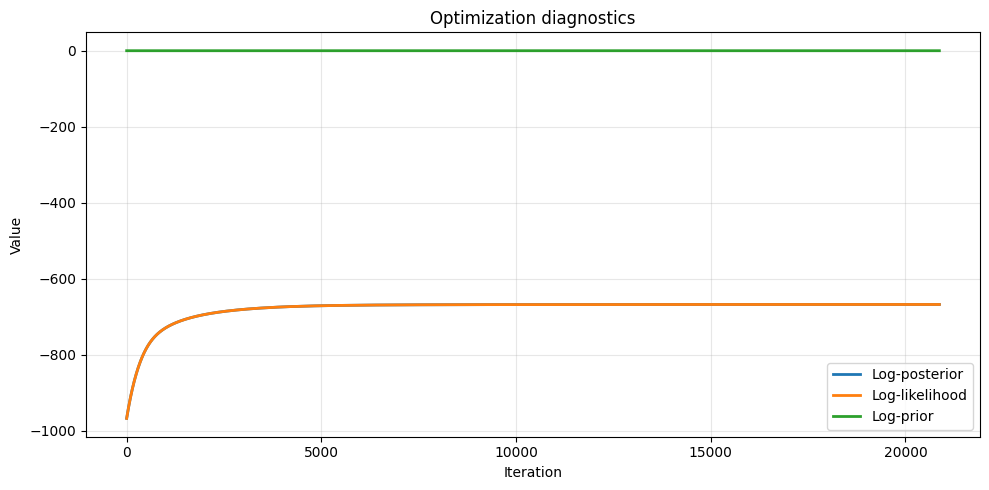

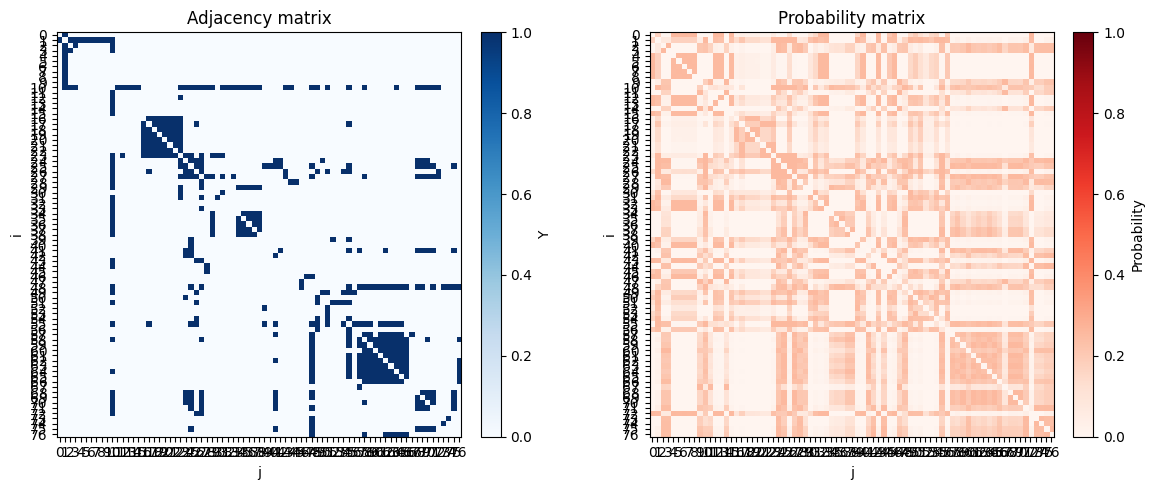

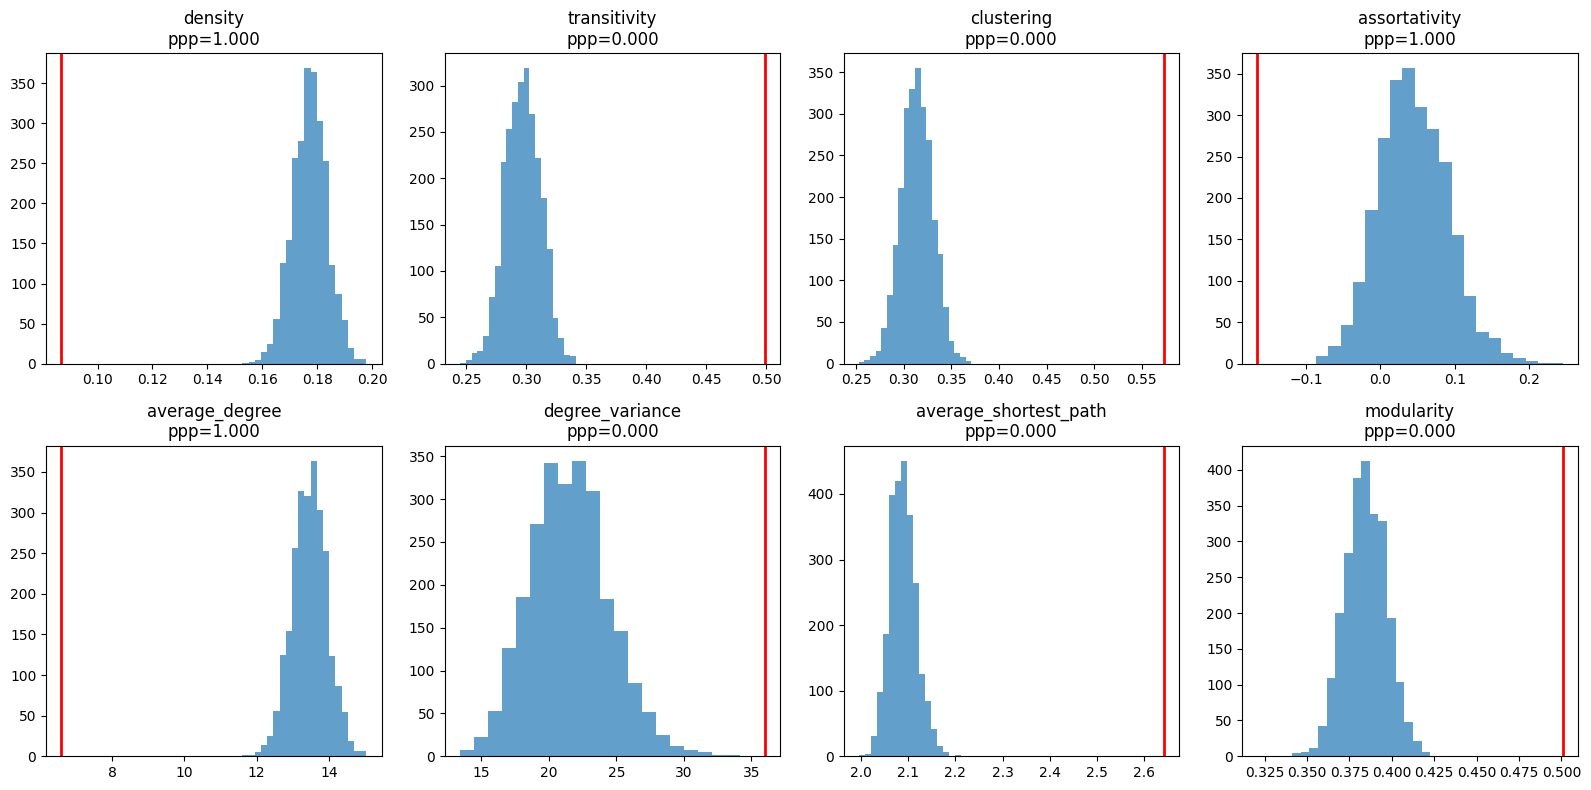

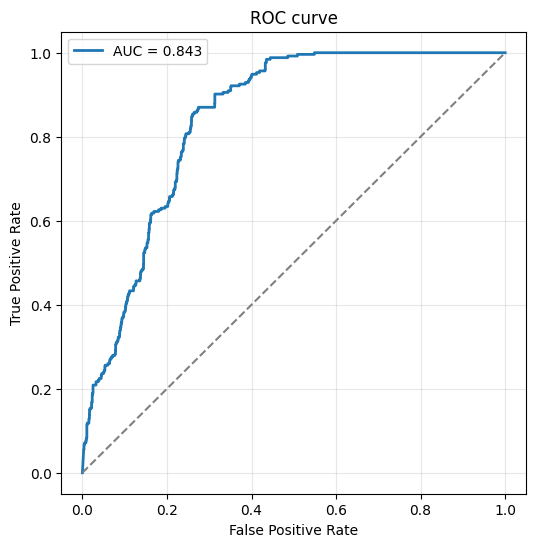

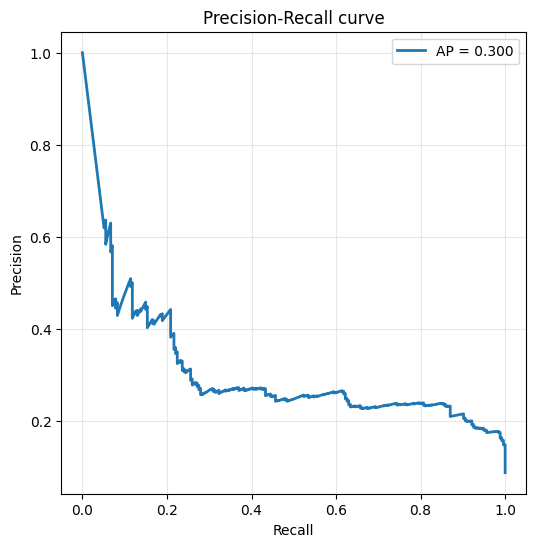

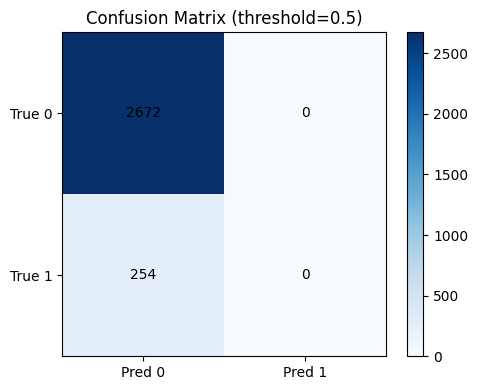

MAP: 100%|██████████| 1000/1000 [00:04<00:00, 228.59it/s, logpost=-524.1101, loglik=-524.1101, logprior=0.0000, ||grad||=0.0100, patience=0]


{'mean_auc': 0.8320066381001812, 'std_auc': 0.0167835990152075, 'min_auc': np.float64(0.8070904251028475), 'max_auc': np.float64(0.8579213184476342), 'n_folds': 5}


In [19]:
geometry = HyperbolicGeometry(d=1, D=diam)
model = LatentSpaceModel(Y=Y, geometry=geometry, fixed_params={"Z": Z, "alpha0": alpha0})
inference = MAPInference(model, lr=lr_MAP)
result = inference.fit_multi_start(n_starts=n_starts_MAP, n_iter=n_iter_MAP, verbose=True, use_tqdm=True)

analysis = ModelAnalysis(model,inference_key="MAP")
analysis.plot_logposterior_trace()
analysis.compare_with_adjacency(analysis.P,title="Probability matrix")
analysis.internal_validation(n_sim=n_sim_iv)
analysis.plot_ppc_distributions()
analysis.laplacian_validation() 
analysis.binary_prediction_metrics()
analysis.plot_roc_curve()
analysis.plot_precision_recall_curve()
analysis.confusion_matrix(threshold=0.5)
analysis.cross_validation(n_folds=n_folds_cv, seed=seed_MAP, n_iter=n_iter_cv, lr=lr_MAP)
print(analysis.cross_validation_summary())

model.save("LesMiserables_H1_p.pkl")

### Model $\mathbb{H}^2$

#### Without weights

In [20]:
with open("LesMiserables_R2_p.pkl", "rb") as f:
    results_R2_p = pickle.load(f)

Z_init = np.zeros((n,3))
Z_init[:,0:2] = np.asarray(results_R2_p['latent_params']['Z'])

Multi_start (1)


MAP:   3%|▎         | 791/25000 [00:05<02:35, 155.34it/s, logpost=-465.6086, loglik=-464.9898, logprior=-0.6188, ||grad||=0.0140, patience=100]


[STOP] Early stopping at iter 790 (no improvement in 101 steps)

Best log-posterior: -465.6086


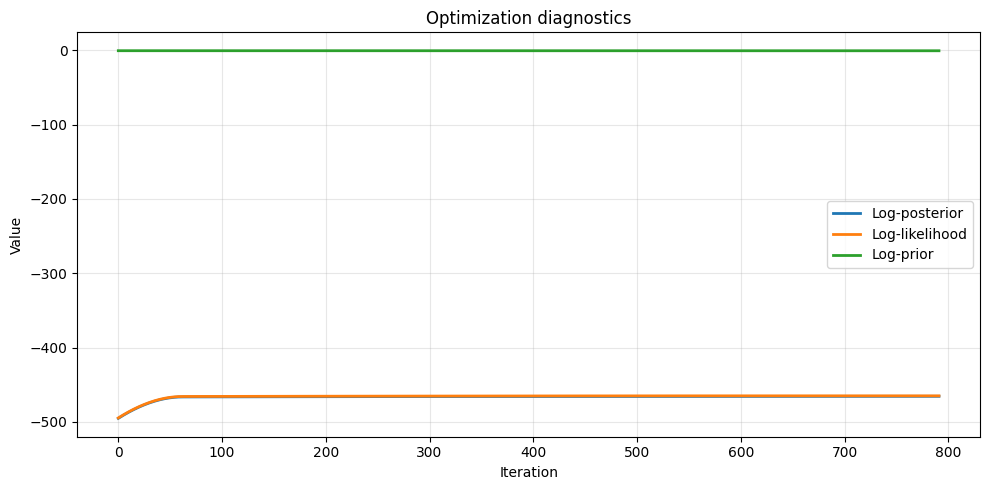

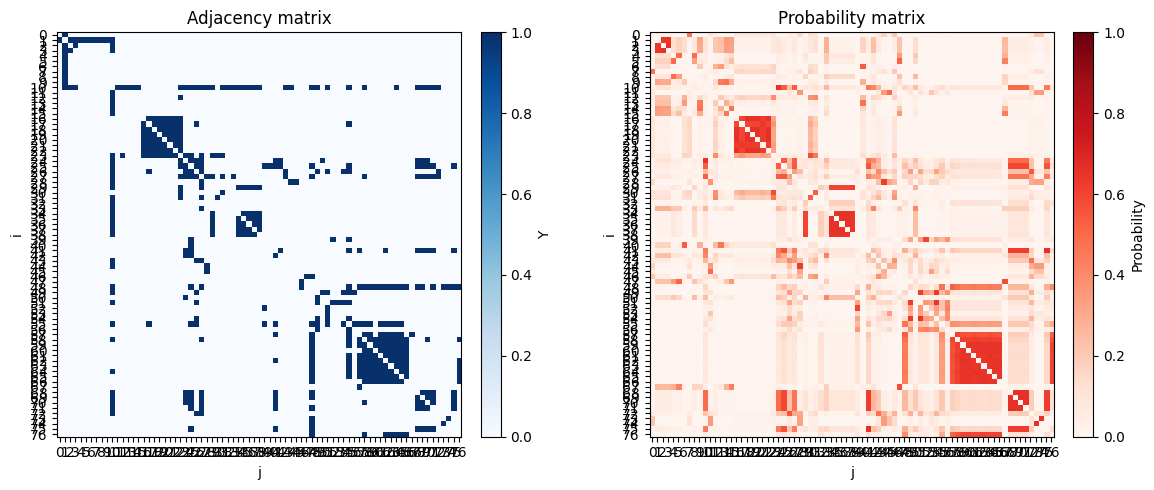

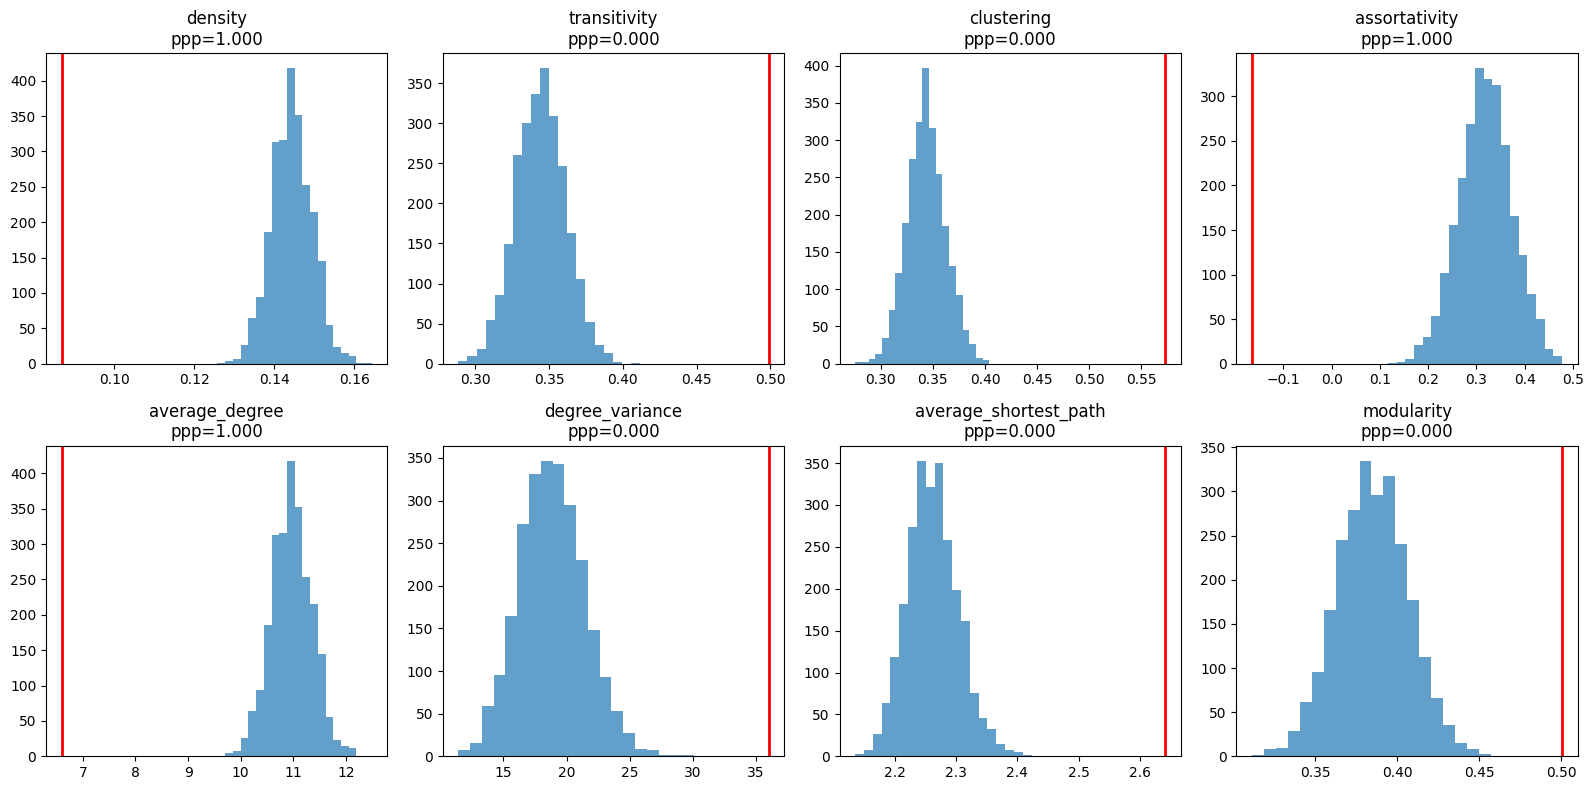

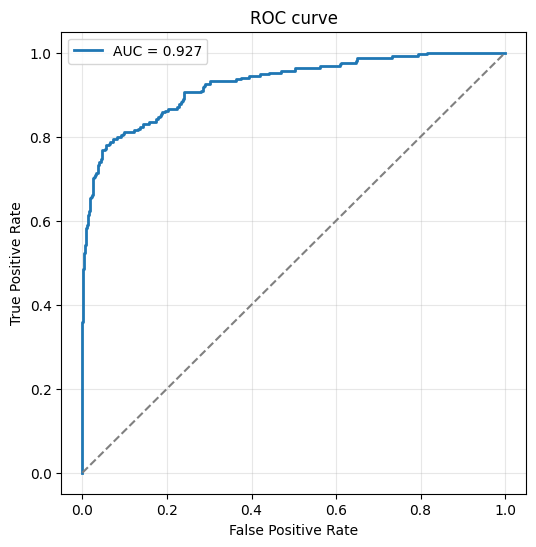

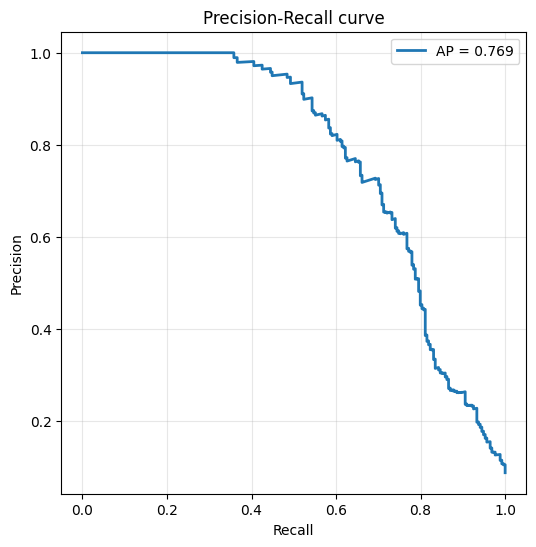

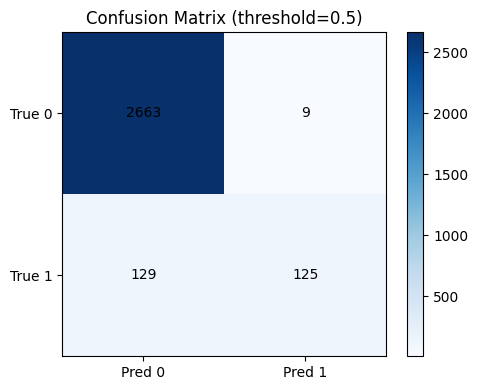

MAP:   6%|▌         | 55/1000 [00:00<00:17, 55.46it/s, logpost=-369.7555, loglik=-369.1349, logprior=-0.6205, ||grad||=0.0141, patience=49]


{'mean_auc': 0.92770516834626, 'std_auc': 0.015871348706450426, 'min_auc': np.float64(0.9064659755449229), 'max_auc': np.float64(0.9515566914498141), 'n_folds': 5}


In [21]:
geometry = HyperbolicGeometry(d=2, D=diam)
model = LatentSpaceModel(Y=Y, geometry=geometry, fixed_params={"xi": np.ones(n)})
inference = MAPInference(model, lr=lr_MAP)
result = inference.fit_multi_start(n_starts=n_starts_MAP, n_iter=n_iter_MAP, verbose=True, use_tqdm=True, init_params = {"alpha0":0.0,"Z": Z_init})

analysis = ModelAnalysis(model,inference_key="MAP")
analysis.plot_logposterior_trace()
analysis.compare_with_adjacency(analysis.P,title="Probability matrix")
analysis.internal_validation(n_sim=n_sim_iv)
analysis.plot_ppc_distributions()
analysis.laplacian_validation() 
analysis.binary_prediction_metrics()
analysis.plot_roc_curve()
analysis.plot_precision_recall_curve()
analysis.confusion_matrix(threshold=0.5)
analysis.cross_validation(n_folds=n_folds_cv, seed=seed_MAP, n_iter=n_iter_cv, lr=lr_MAP)
print(analysis.cross_validation_summary())

model.save("LesMiserables_H2_c.pkl")

alpha0 = model.inferred["MAP"]["final_params"]["alpha0"]
Z = model.inferred["MAP"]["final_params"]["Z"]

#### With weights

Multi_start (1)


MAP:  14%|█▍        | 3527/25000 [00:13<01:19, 268.49it/s, logpost=-388.9317, loglik=-388.9317, logprior=0.0000, ||grad||=0.0100, patience=100]


[STOP] Early stopping at iter 3526 (no improvement in 101 steps)

Best log-posterior: -388.9317


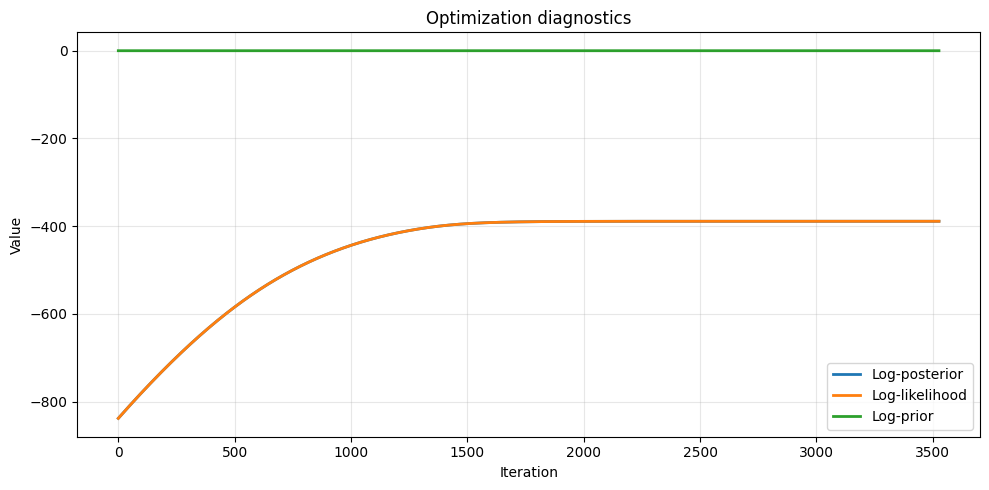

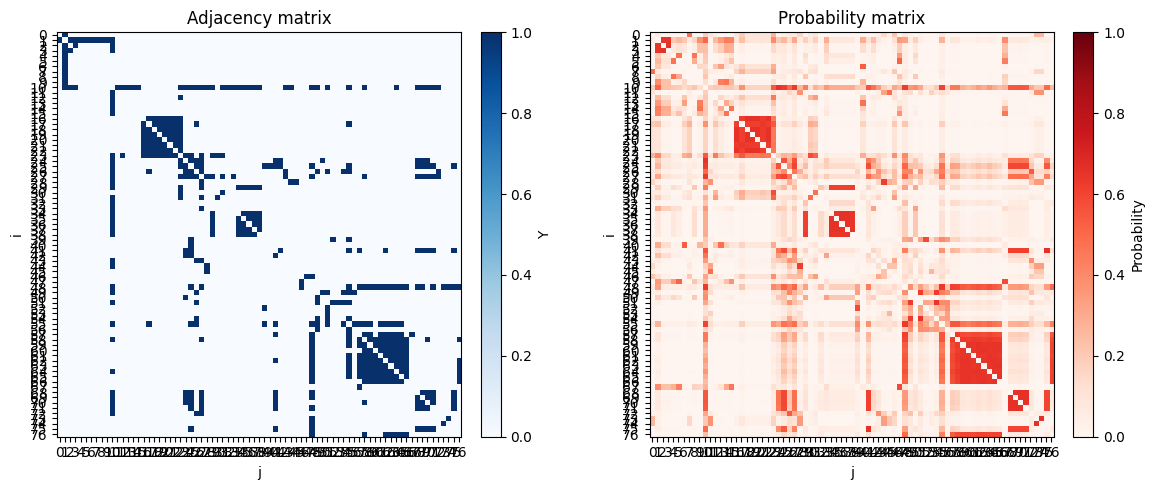

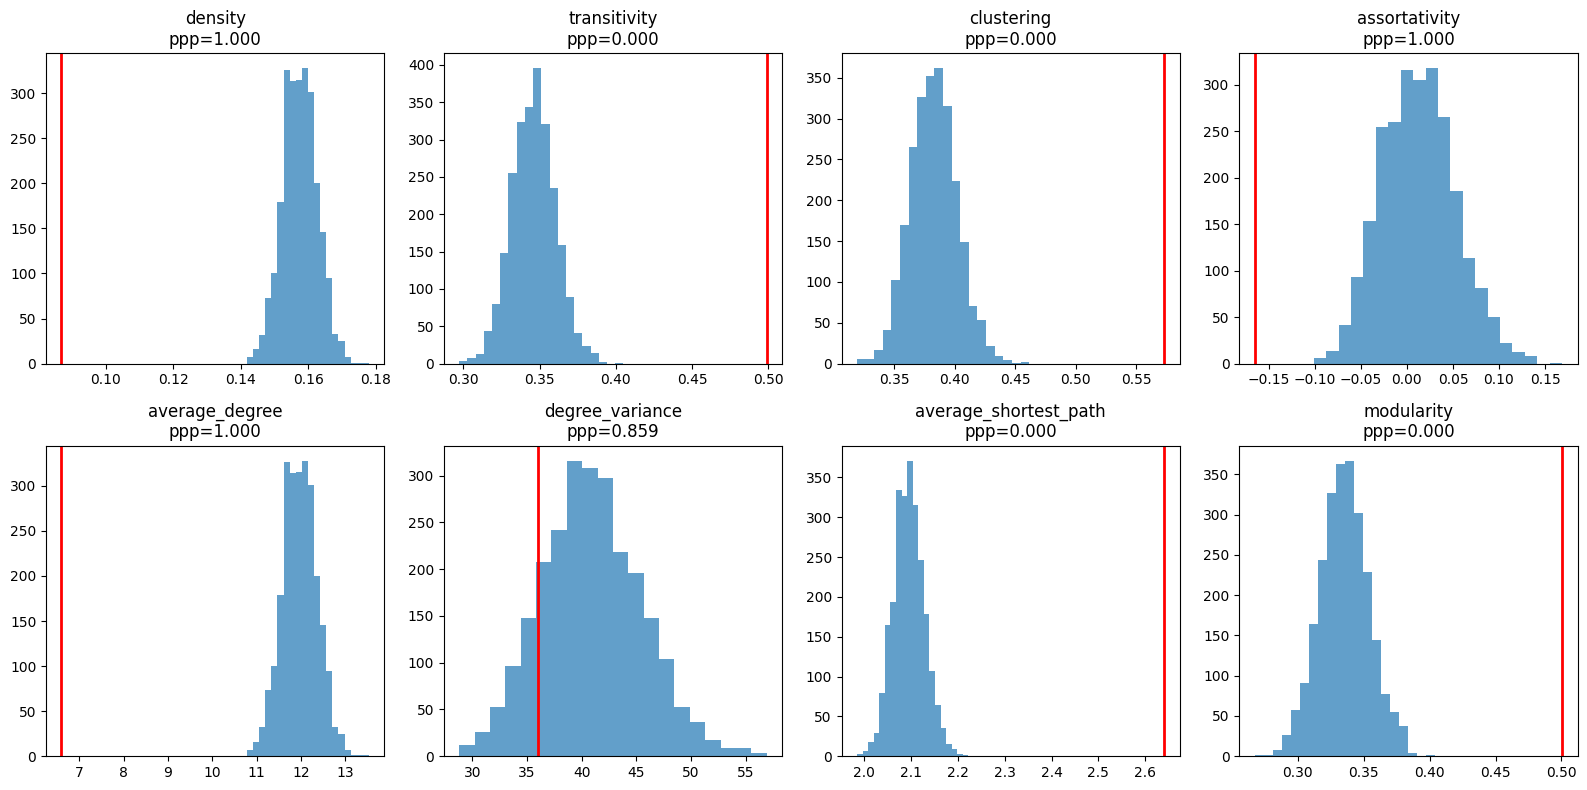

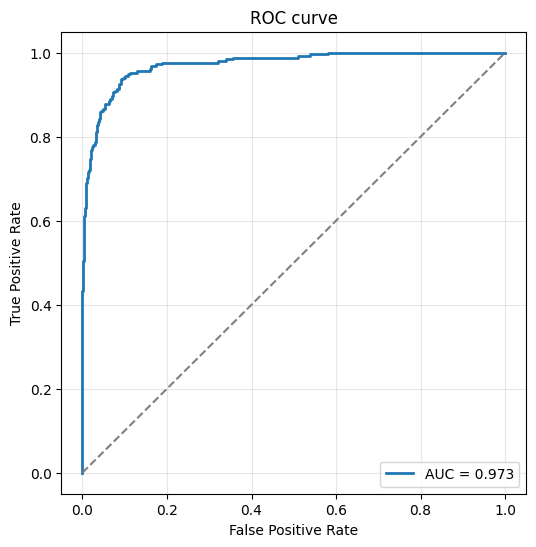

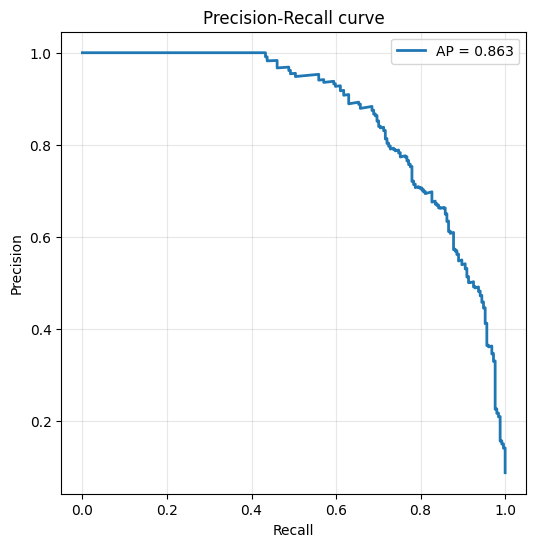

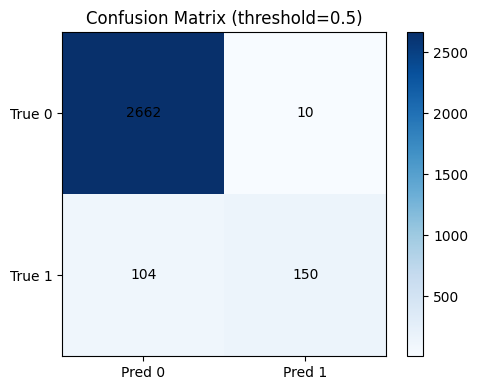

MAP: 100%|██████████| 1000/1000 [00:04<00:00, 247.69it/s, logpost=-307.2803, loglik=-307.2803, logprior=0.0000, ||grad||=0.0090, patience=2]


{'mean_auc': 0.9565921322741696, 'std_auc': 0.013420280256851717, 'min_auc': np.float64(0.9412546517809675), 'max_auc': np.float64(0.9771530359355638), 'n_folds': 5}


In [22]:
geometry = HyperbolicGeometry(d=2, D=diam)
model = LatentSpaceModel(Y=Y, geometry=geometry, fixed_params={"Z": Z, "alpha0": alpha0})
inference = MAPInference(model, lr=lr_MAP)
result = inference.fit_multi_start(n_starts=n_starts_MAP, n_iter=n_iter_MAP, verbose=True, use_tqdm=True)

analysis = ModelAnalysis(model,inference_key="MAP")
analysis.plot_logposterior_trace()
analysis.compare_with_adjacency(analysis.P,title="Probability matrix")
analysis.internal_validation(n_sim=n_sim_iv)
analysis.plot_ppc_distributions()
analysis.laplacian_validation() 
analysis.binary_prediction_metrics()
analysis.plot_roc_curve()
analysis.plot_precision_recall_curve()
analysis.confusion_matrix(threshold=0.5)
analysis.cross_validation(n_folds=n_folds_cv, seed=seed_MAP, n_iter=n_iter_cv, lr=0.9*lr_MAP)
print(analysis.cross_validation_summary())

model.save("LesMiserables_H2_p.pkl")

## Results